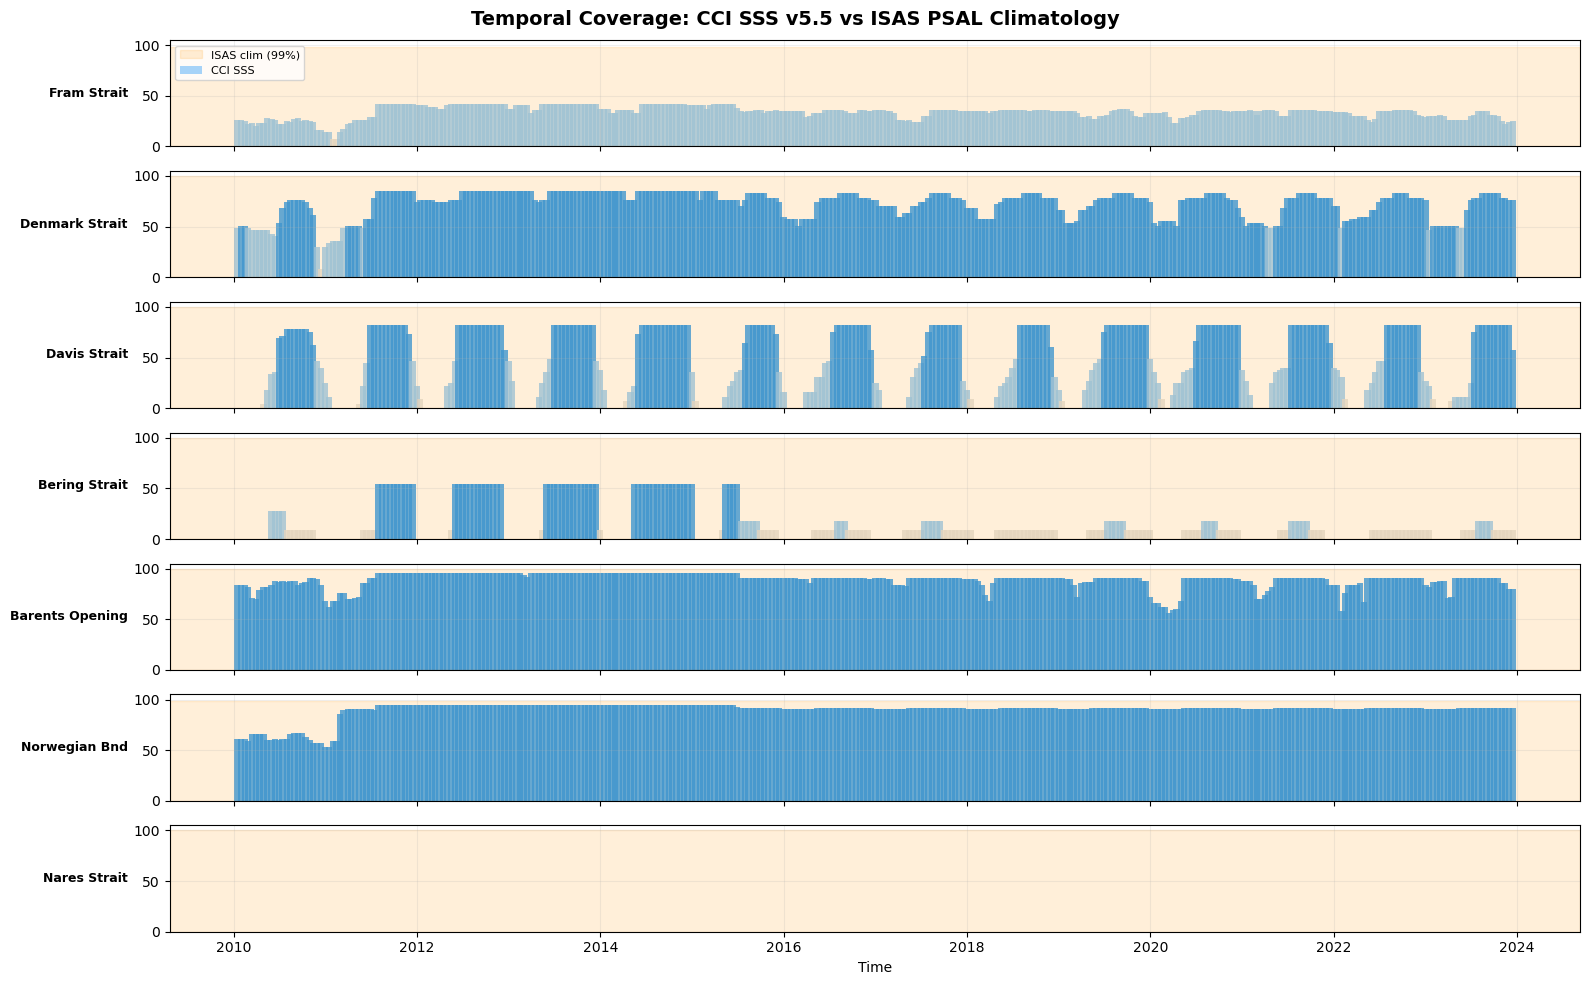


════════════════════════════════════════════════════════════════════════════════════════════════════
  SUMMARY: CCI SSS v5.5 vs ISAS PSAL
════════════════════════════════════════════════════════════════════════════════════════════════════
  Gate                 │ CCI: time range              │ CCI pts  │ CCI valid% │ ISAS pts  │ ISAS depths
────────────────────────────────────────────────────────────────────────────────────────────────────
  Fram Strait          │ 2010-01 → 2023-12            │ 120      │    33.8%  │ 70        │ 187 levels
  Denmark Strait       │ 2010-01 → 2023-12            │ 47       │    72.4%  │ 25        │ 187 levels
  Davis Strait         │ 2010-01 → 2023-12            │ 45       │    45.2%  │ 24        │ 187 levels
  Bering Strait        │ 2010-01 → 2023-12            │ 11       │    14.5%  │ 6         │ 187 levels
  Barents Opening      │ 2010-01 → 2023-12            │ 76       │    89.1%  │ 56        │ 187 levels
  Norwegian Bnd        │ 2010-01 → 2023-12   

In [ ]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

NC = Path("/Users/nicolocaron/Desktop/ARCFRESH/straits/netcdf")

GATES = {
    "Fram Strait":     ("fram_strait_S3_pass_481",     "fram_strait_S3_pass_481"),
    "Denmark Strait":  ("denmark_strait_TPJ_pass_246",  "denmark_strait_TPJ_pass_246"),
    "Davis Strait":    ("davis_strait",                 "davis_strait"),
    "Bering Strait":   ("bering_strait_TPJ_pass_076",   "bering_strait_TPJ_pass_076"),
    "Barents Opening": ("barents_sea_opening_S3_pass_481", "barents_sea_opening_S3_pass_481"),
    "Norwegian Bnd":   ("norwegian_sea_boundary_TPJ_pass_220", "norwegian_sea_boundary_TPJ_pass_220"),
    "Nares Strait":    ("nares_strait",                 "nares_strait"),
}

# ═══════════════════════════════════════════════════════════════
# 1. TEMPORAL RANGE + COVERAGE OVERVIEW
# ═══════════════════════════════════════════════════════════════
fig, axes = plt.subplots(len(GATES), 1, figsize=(16, 10), sharex=True)
fig.suptitle("Temporal Coverage: CCI SSS v5.5 vs ISAS PSAL Climatology", fontsize=14, fontweight='bold')

for idx, (gate_name, (cci_prefix, isas_prefix)) in enumerate(GATES.items()):
    ax = axes[idx]
    
    # CCI SSS
    ds_cci = xr.open_dataset(NC / f"{cci_prefix}_SSS_CCIv5.5.nc")
    cci_dates = pd.to_datetime(ds_cci['date'].values)
    cci_sss = ds_cci['sss'].values  # (time, nb_prof)
    cci_valid_pct = np.array([(~np.isnan(cci_sss[t, :])).sum() / cci_sss.shape[1] * 100 for t in range(len(cci_dates))])
    ds_cci.close()
    
    # Plot CCI coverage as colored bars
    colors_cci = ['#2196F3' if v > 50 else '#90CAF9' if v > 10 else '#E0E0E0' for v in cci_valid_pct]
    ax.bar(cci_dates, cci_valid_pct, width=25, color=colors_cci, alpha=0.8, label='CCI SSS')
    
    # ISAS — 12 months climatology (no interannual variability)
    ds_isas = xr.open_dataset(NC / f"{isas_prefix}_CLIM_ISAS_PSAL.nc")
    isas_dates = pd.to_datetime(ds_isas['date'].values)
    isas_psal = ds_isas['PSAL'].values  # (time=12, z=187, nb_prof)
    isas_surf = isas_psal[:, 0, :]  # surface layer
    isas_valid_pct = np.array([(~np.isnan(isas_surf[t, :])).sum() / isas_surf.shape[1] * 100 for t in range(12)])
    ds_isas.close()
    
    # Show ISAS as a horizontal band (it's a climatology, applies to all years)
    isas_mean_valid = np.mean(isas_valid_pct)
    ax.axhspan(0, isas_mean_valid, alpha=0.15, color='#FF9800', label=f'ISAS clim ({isas_mean_valid:.0f}%)')
    
    ax.set_ylabel(gate_name, fontsize=9, fontweight='bold', rotation=0, ha='right', va='center')
    ax.set_ylim(0, 105)
    ax.set_yticks([0, 50, 100])
    ax.grid(True, alpha=0.2)
    if idx == 0:
        ax.legend(loc='upper left', fontsize=8)

axes[-1].set_xlabel("Time")
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[-1].xaxis.set_major_locator(mdates.YearLocator(2))

plt.tight_layout()
plt.show()

# ═══════════════════════════════════════════════════════════════
# Print summary table
# ═══════════════════════════════════════════════════════════════
print("\n" + "═" * 100)
print("  SUMMARY: CCI SSS v5.5 vs ISAS PSAL")
print("═" * 100)
print(f"  {'Gate':<20} │ {'CCI: time range':<28} │ {'CCI pts':<8} │ {'CCI valid%':<10} │ {'ISAS pts':<9} │ {'ISAS depths'}")
print("─" * 100)

for gate_name, (cci_prefix, isas_prefix) in GATES.items():
    ds_cci = xr.open_dataset(NC / f"{cci_prefix}_SSS_CCIv5.5.nc")
    cci_dates = pd.to_datetime(ds_cci['date'].values)
    cci_sss = ds_cci['sss'].values
    cci_valid = (~np.isnan(cci_sss)).sum() / cci_sss.size * 100
    n_cci = cci_sss.shape[1]
    ds_cci.close()
    
    ds_isas = xr.open_dataset(NC / f"{isas_prefix}_CLIM_ISAS_PSAL.nc")
    n_isas = ds_isas['PSAL'].shape[2]
    n_z = ds_isas['PSAL'].shape[1]
    ds_isas.close()
    
    t_range = f"{cci_dates[0].strftime('%Y-%m')} → {cci_dates[-1].strftime('%Y-%m')}"
    print(f"  {gate_name:<20} │ {t_range:<28} │ {n_cci:<8} │ {cci_valid:>7.1f}%  │ {n_isas:<9} │ {n_z} levels")


/var/folders/q5/g4rsymgj6137bp73lx06r3g40000gn/T/ipykernel_54350/3863956913.py:53: RuntimeWarning: Mean of empty slice
  monthly = np.nanmean(sss[mask, :], axis=0)
/var/folders/q5/g4rsymgj6137bp73lx06r3g40000gn/T/ipykernel_54350/3863956913.py:53: RuntimeWarning: Mean of empty slice
  monthly = np.nanmean(sss[mask, :], axis=0)
/var/folders/q5/g4rsymgj6137bp73lx06r3g40000gn/T/ipykernel_54350/3863956913.py:53: RuntimeWarning: Mean of empty slice
  monthly = np.nanmean(sss[mask, :], axis=0)
/var/folders/q5/g4rsymgj6137bp73lx06r3g40000gn/T/ipykernel_54350/3863956913.py:53: RuntimeWarning: Mean of empty slice
  monthly = np.nanmean(sss[mask, :], axis=0)
/var/folders/q5/g4rsymgj6137bp73lx06r3g40000gn/T/ipykernel_54350/3863956913.py:53: RuntimeWarning: Mean of empty slice
  monthly = np.nanmean(sss[mask, :], axis=0)
/var/folders/q5/g4rsymgj6137bp73lx06r3g40000gn/T/ipykernel_54350/3863956913.py:53: RuntimeWarning: Mean of empty slice
  monthly = np.nanmean(sss[mask, :], axis=0)
/var/folders/q5/

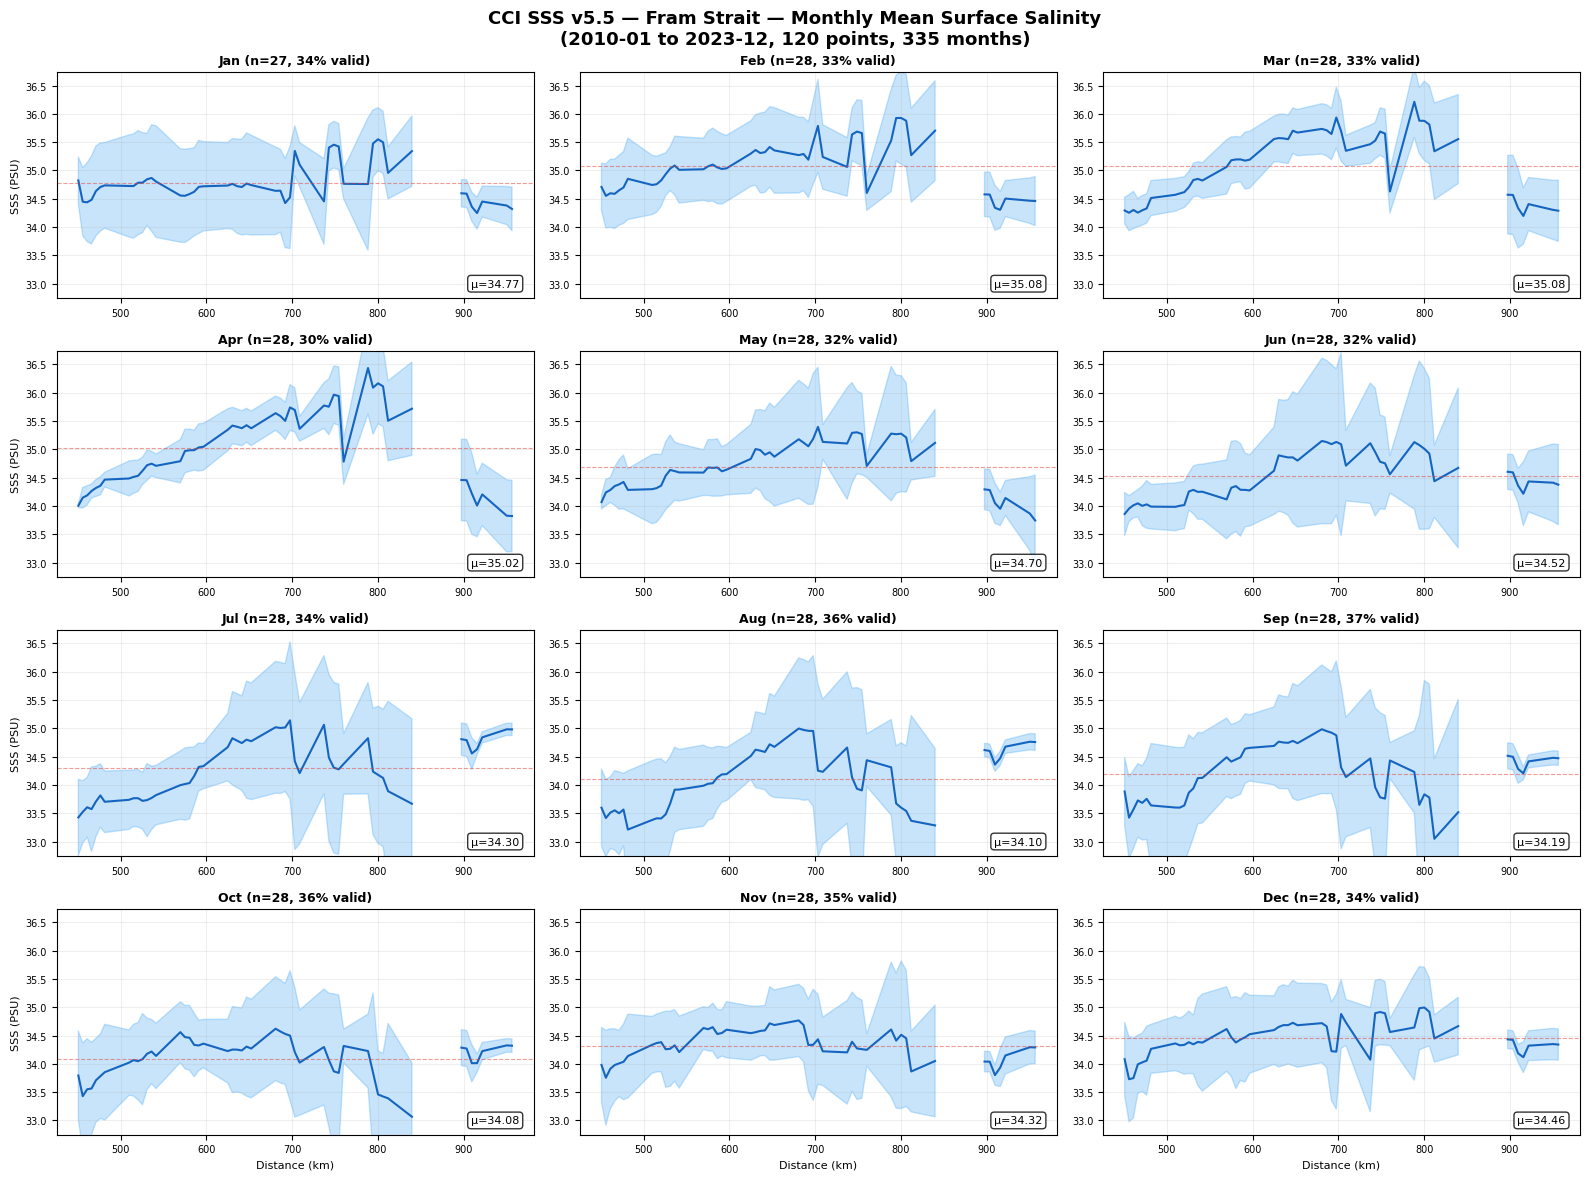

/var/folders/q5/g4rsymgj6137bp73lx06r3g40000gn/T/ipykernel_54350/3863956913.py:53: RuntimeWarning: Mean of empty slice
  monthly = np.nanmean(sss[mask, :], axis=0)
/var/folders/q5/g4rsymgj6137bp73lx06r3g40000gn/T/ipykernel_54350/3863956913.py:53: RuntimeWarning: Mean of empty slice
  monthly = np.nanmean(sss[mask, :], axis=0)
/var/folders/q5/g4rsymgj6137bp73lx06r3g40000gn/T/ipykernel_54350/3863956913.py:53: RuntimeWarning: Mean of empty slice
  monthly = np.nanmean(sss[mask, :], axis=0)
/var/folders/q5/g4rsymgj6137bp73lx06r3g40000gn/T/ipykernel_54350/3863956913.py:53: RuntimeWarning: Mean of empty slice
  monthly = np.nanmean(sss[mask, :], axis=0)
/var/folders/q5/g4rsymgj6137bp73lx06r3g40000gn/T/ipykernel_54350/3863956913.py:53: RuntimeWarning: Mean of empty slice
  monthly = np.nanmean(sss[mask, :], axis=0)
/var/folders/q5/g4rsymgj6137bp73lx06r3g40000gn/T/ipykernel_54350/3863956913.py:53: RuntimeWarning: Mean of empty slice
  monthly = np.nanmean(sss[mask, :], axis=0)
/var/folders/q5/

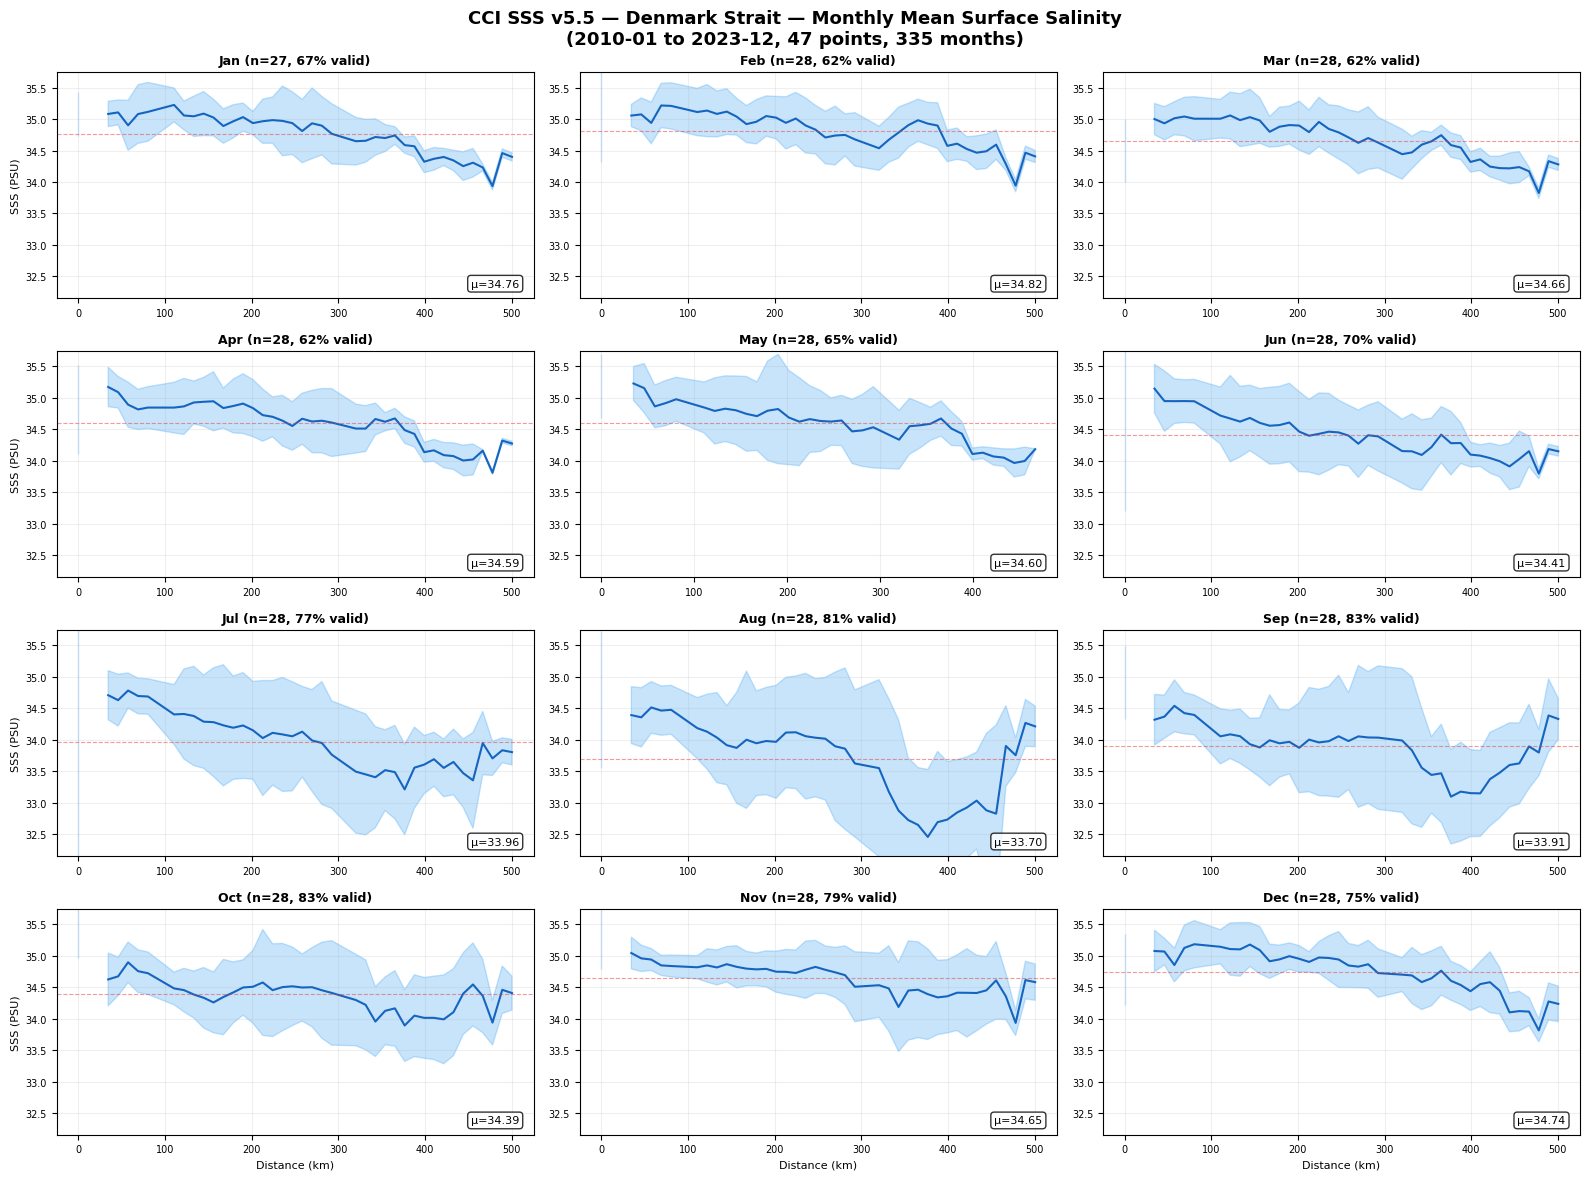

/var/folders/q5/g4rsymgj6137bp73lx06r3g40000gn/T/ipykernel_54350/3863956913.py:53: RuntimeWarning: Mean of empty slice
  monthly = np.nanmean(sss[mask, :], axis=0)
/var/folders/q5/g4rsymgj6137bp73lx06r3g40000gn/T/ipykernel_54350/3863956913.py:53: RuntimeWarning: Mean of empty slice
  monthly = np.nanmean(sss[mask, :], axis=0)
/var/folders/q5/g4rsymgj6137bp73lx06r3g40000gn/T/ipykernel_54350/3863956913.py:53: RuntimeWarning: Mean of empty slice
  monthly = np.nanmean(sss[mask, :], axis=0)
/var/folders/q5/g4rsymgj6137bp73lx06r3g40000gn/T/ipykernel_54350/3863956913.py:53: RuntimeWarning: Mean of empty slice
  monthly = np.nanmean(sss[mask, :], axis=0)
/var/folders/q5/g4rsymgj6137bp73lx06r3g40000gn/T/ipykernel_54350/3863956913.py:53: RuntimeWarning: Mean of empty slice
  monthly = np.nanmean(sss[mask, :], axis=0)
/var/folders/q5/g4rsymgj6137bp73lx06r3g40000gn/T/ipykernel_54350/3863956913.py:53: RuntimeWarning: Mean of empty slice
  monthly = np.nanmean(sss[mask, :], axis=0)
/var/folders/q5/

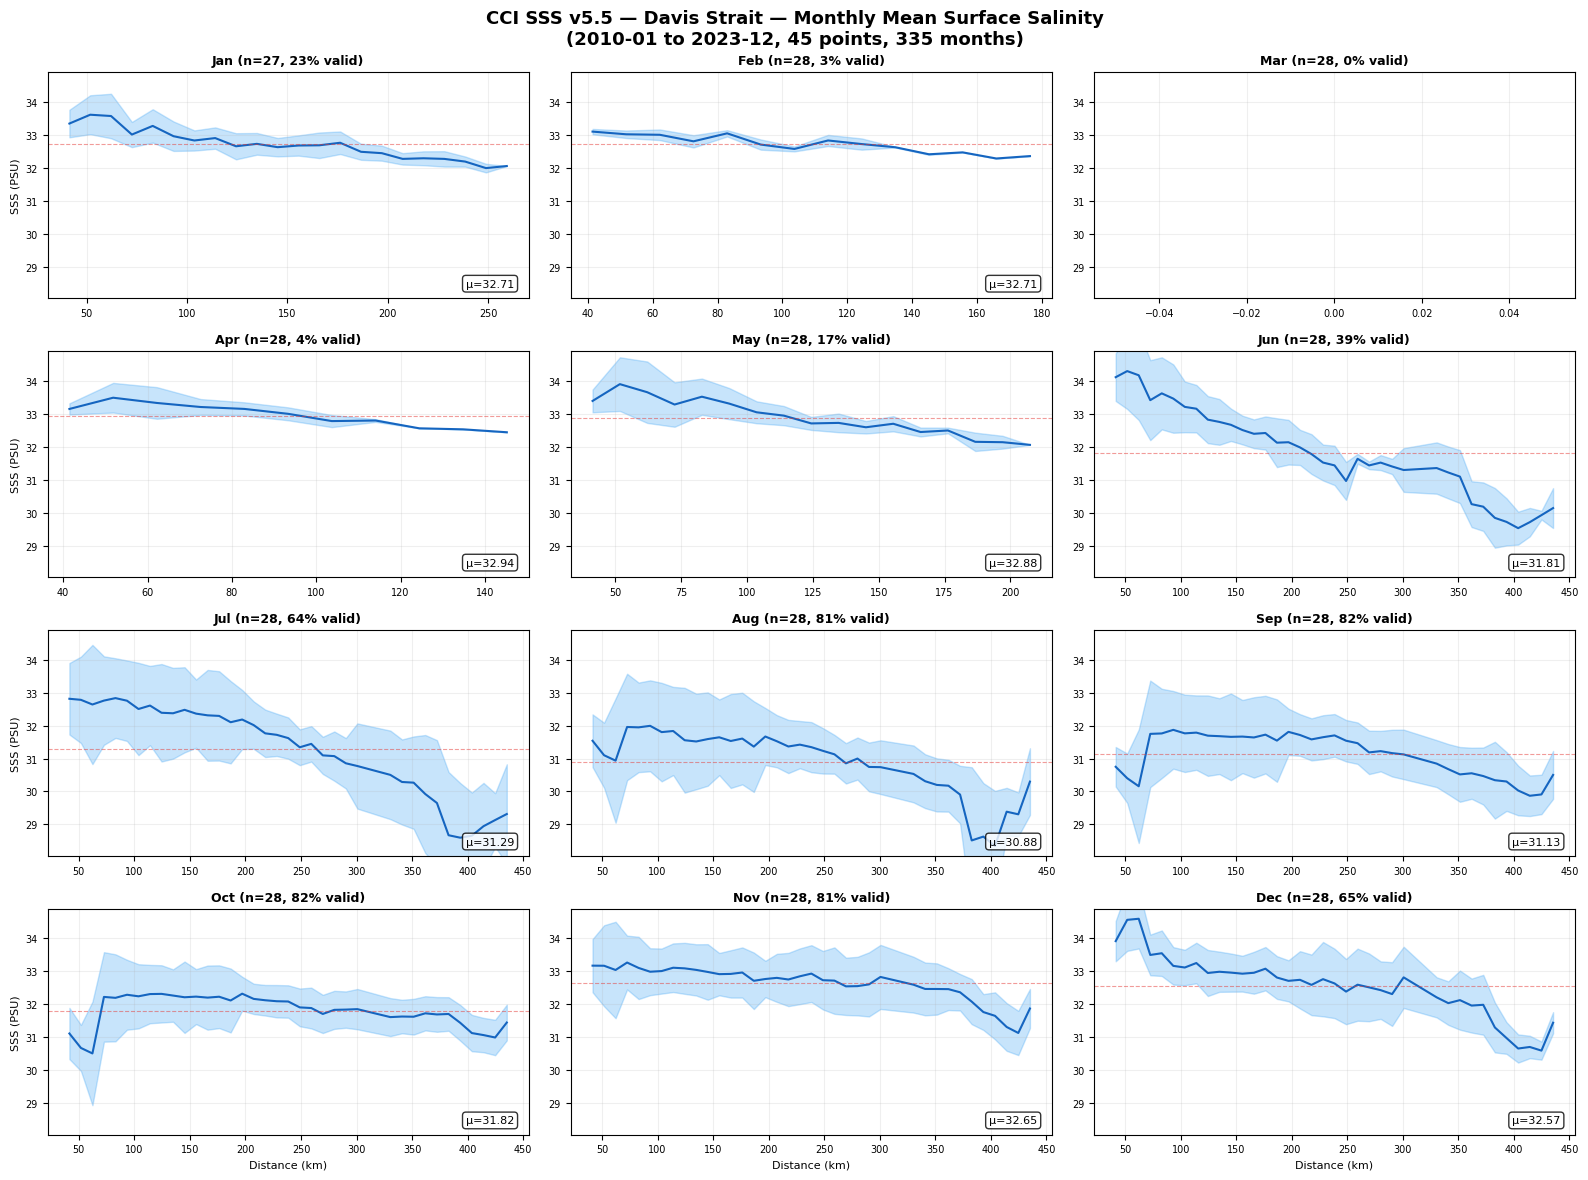

/var/folders/q5/g4rsymgj6137bp73lx06r3g40000gn/T/ipykernel_54350/3863956913.py:53: RuntimeWarning: Mean of empty slice
  monthly = np.nanmean(sss[mask, :], axis=0)
/var/folders/q5/g4rsymgj6137bp73lx06r3g40000gn/T/ipykernel_54350/3863956913.py:53: RuntimeWarning: Mean of empty slice
  monthly = np.nanmean(sss[mask, :], axis=0)
/var/folders/q5/g4rsymgj6137bp73lx06r3g40000gn/T/ipykernel_54350/3863956913.py:53: RuntimeWarning: Mean of empty slice
  monthly = np.nanmean(sss[mask, :], axis=0)
/var/folders/q5/g4rsymgj6137bp73lx06r3g40000gn/T/ipykernel_54350/3863956913.py:53: RuntimeWarning: Mean of empty slice
  monthly = np.nanmean(sss[mask, :], axis=0)
/var/folders/q5/g4rsymgj6137bp73lx06r3g40000gn/T/ipykernel_54350/3863956913.py:53: RuntimeWarning: Mean of empty slice
  monthly = np.nanmean(sss[mask, :], axis=0)
/var/folders/q5/g4rsymgj6137bp73lx06r3g40000gn/T/ipykernel_54350/3863956913.py:53: RuntimeWarning: Mean of empty slice
  monthly = np.nanmean(sss[mask, :], axis=0)
/var/folders/q5/

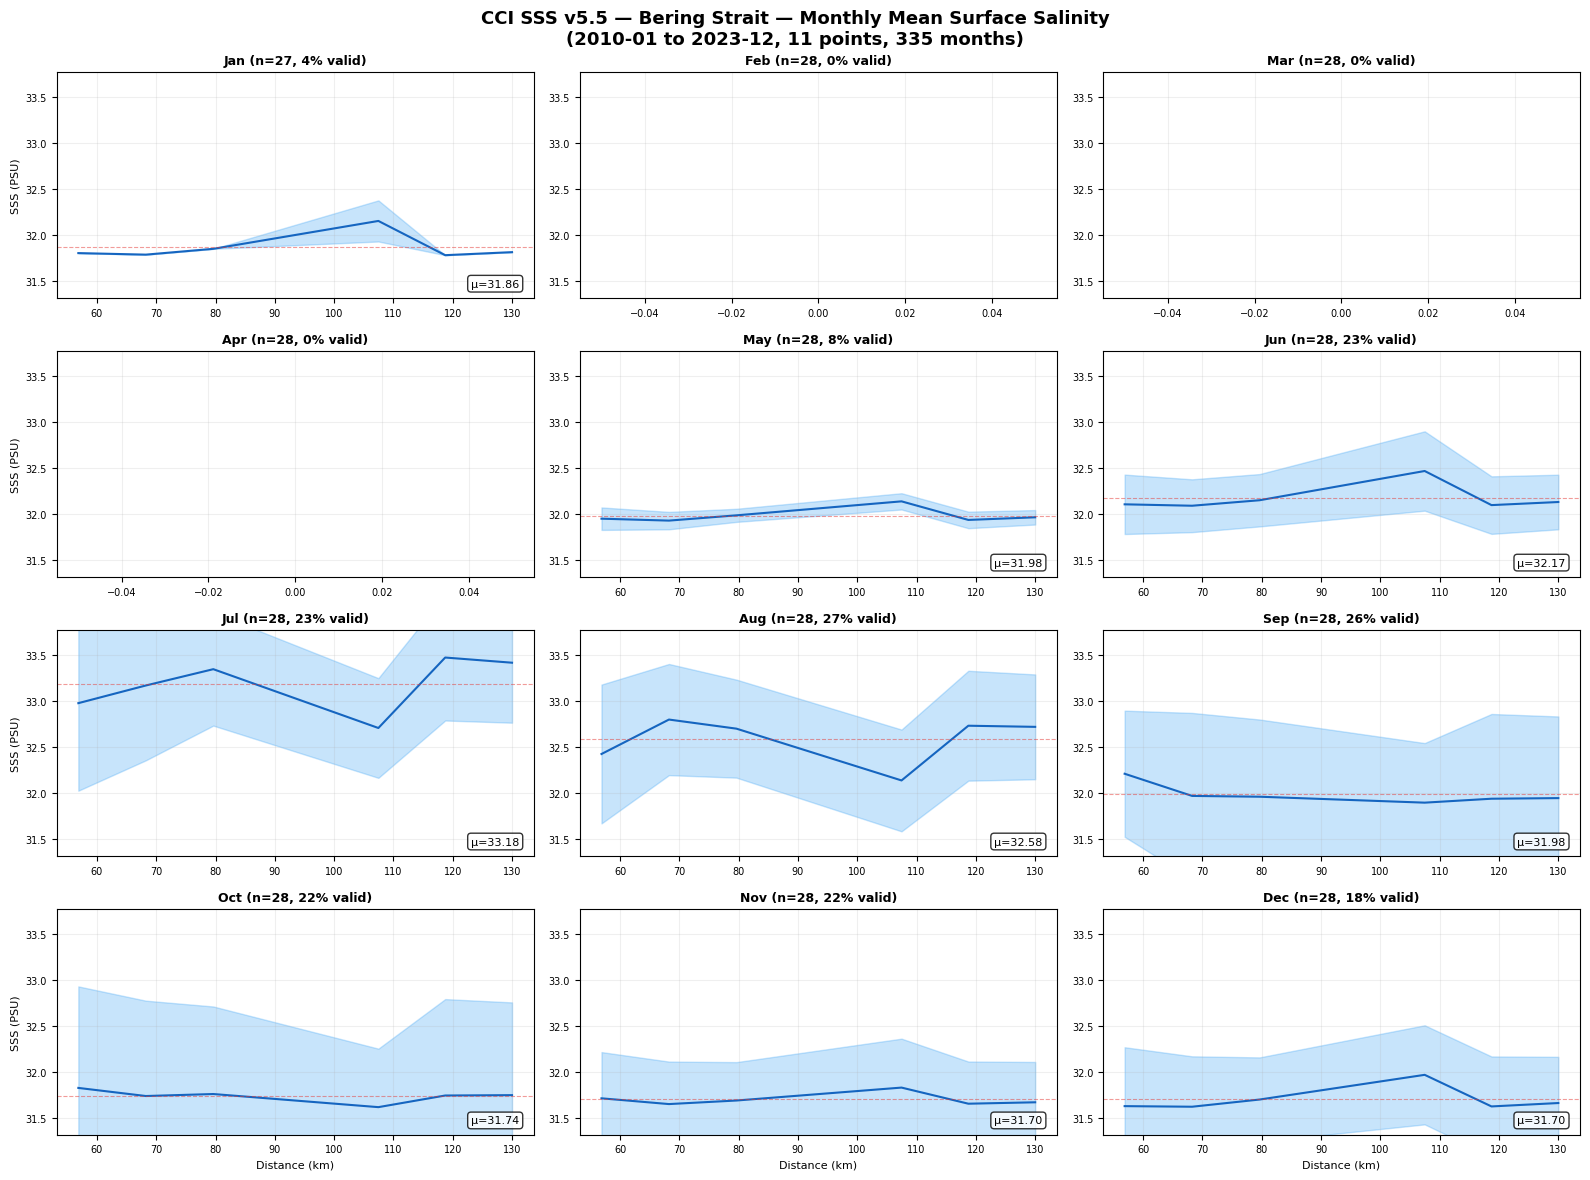

/var/folders/q5/g4rsymgj6137bp73lx06r3g40000gn/T/ipykernel_54350/3863956913.py:53: RuntimeWarning: Mean of empty slice
  monthly = np.nanmean(sss[mask, :], axis=0)
/var/folders/q5/g4rsymgj6137bp73lx06r3g40000gn/T/ipykernel_54350/3863956913.py:53: RuntimeWarning: Mean of empty slice
  monthly = np.nanmean(sss[mask, :], axis=0)
/var/folders/q5/g4rsymgj6137bp73lx06r3g40000gn/T/ipykernel_54350/3863956913.py:53: RuntimeWarning: Mean of empty slice
  monthly = np.nanmean(sss[mask, :], axis=0)
/var/folders/q5/g4rsymgj6137bp73lx06r3g40000gn/T/ipykernel_54350/3863956913.py:53: RuntimeWarning: Mean of empty slice
  monthly = np.nanmean(sss[mask, :], axis=0)
/var/folders/q5/g4rsymgj6137bp73lx06r3g40000gn/T/ipykernel_54350/3863956913.py:53: RuntimeWarning: Mean of empty slice
  monthly = np.nanmean(sss[mask, :], axis=0)
/var/folders/q5/g4rsymgj6137bp73lx06r3g40000gn/T/ipykernel_54350/3863956913.py:53: RuntimeWarning: Mean of empty slice
  monthly = np.nanmean(sss[mask, :], axis=0)
/var/folders/q5/

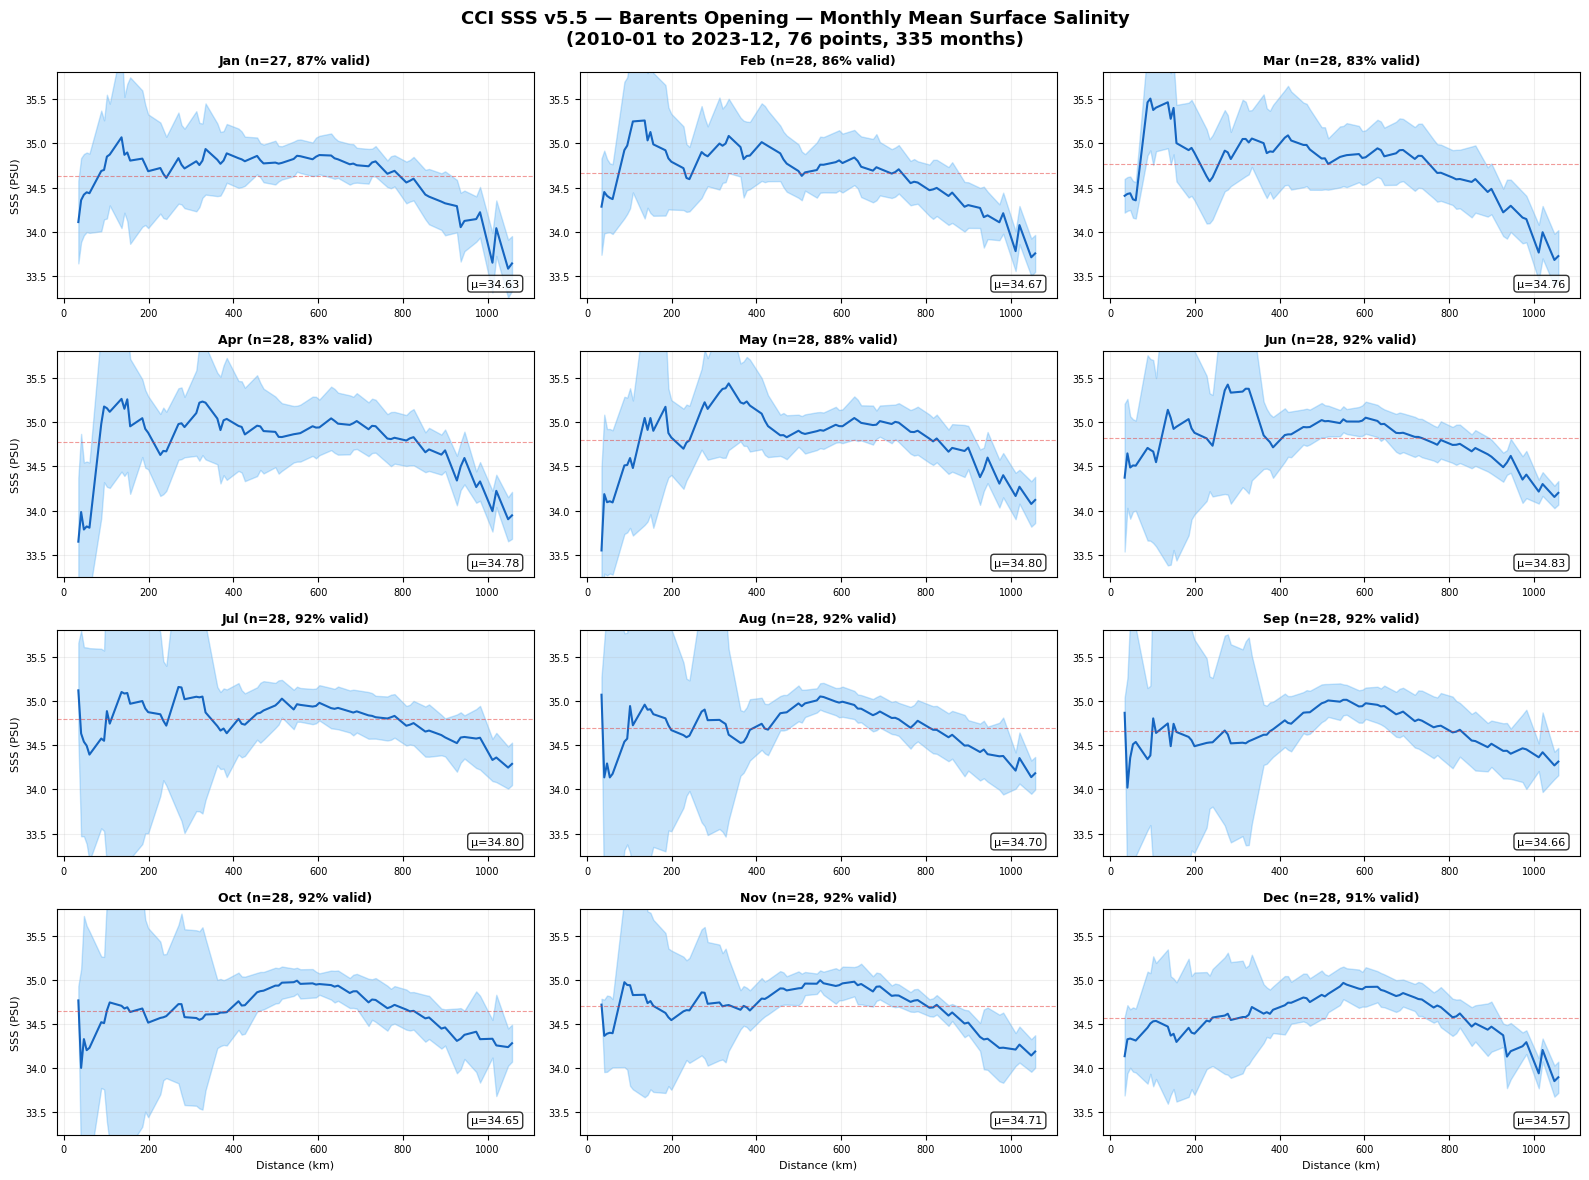

/var/folders/q5/g4rsymgj6137bp73lx06r3g40000gn/T/ipykernel_54350/3863956913.py:53: RuntimeWarning: Mean of empty slice
  monthly = np.nanmean(sss[mask, :], axis=0)
/var/folders/q5/g4rsymgj6137bp73lx06r3g40000gn/T/ipykernel_54350/3863956913.py:53: RuntimeWarning: Mean of empty slice
  monthly = np.nanmean(sss[mask, :], axis=0)
/var/folders/q5/g4rsymgj6137bp73lx06r3g40000gn/T/ipykernel_54350/3863956913.py:53: RuntimeWarning: Mean of empty slice
  monthly = np.nanmean(sss[mask, :], axis=0)
/var/folders/q5/g4rsymgj6137bp73lx06r3g40000gn/T/ipykernel_54350/3863956913.py:53: RuntimeWarning: Mean of empty slice
  monthly = np.nanmean(sss[mask, :], axis=0)
/var/folders/q5/g4rsymgj6137bp73lx06r3g40000gn/T/ipykernel_54350/3863956913.py:53: RuntimeWarning: Mean of empty slice
  monthly = np.nanmean(sss[mask, :], axis=0)
/var/folders/q5/g4rsymgj6137bp73lx06r3g40000gn/T/ipykernel_54350/3863956913.py:53: RuntimeWarning: Mean of empty slice
  monthly = np.nanmean(sss[mask, :], axis=0)
/var/folders/q5/

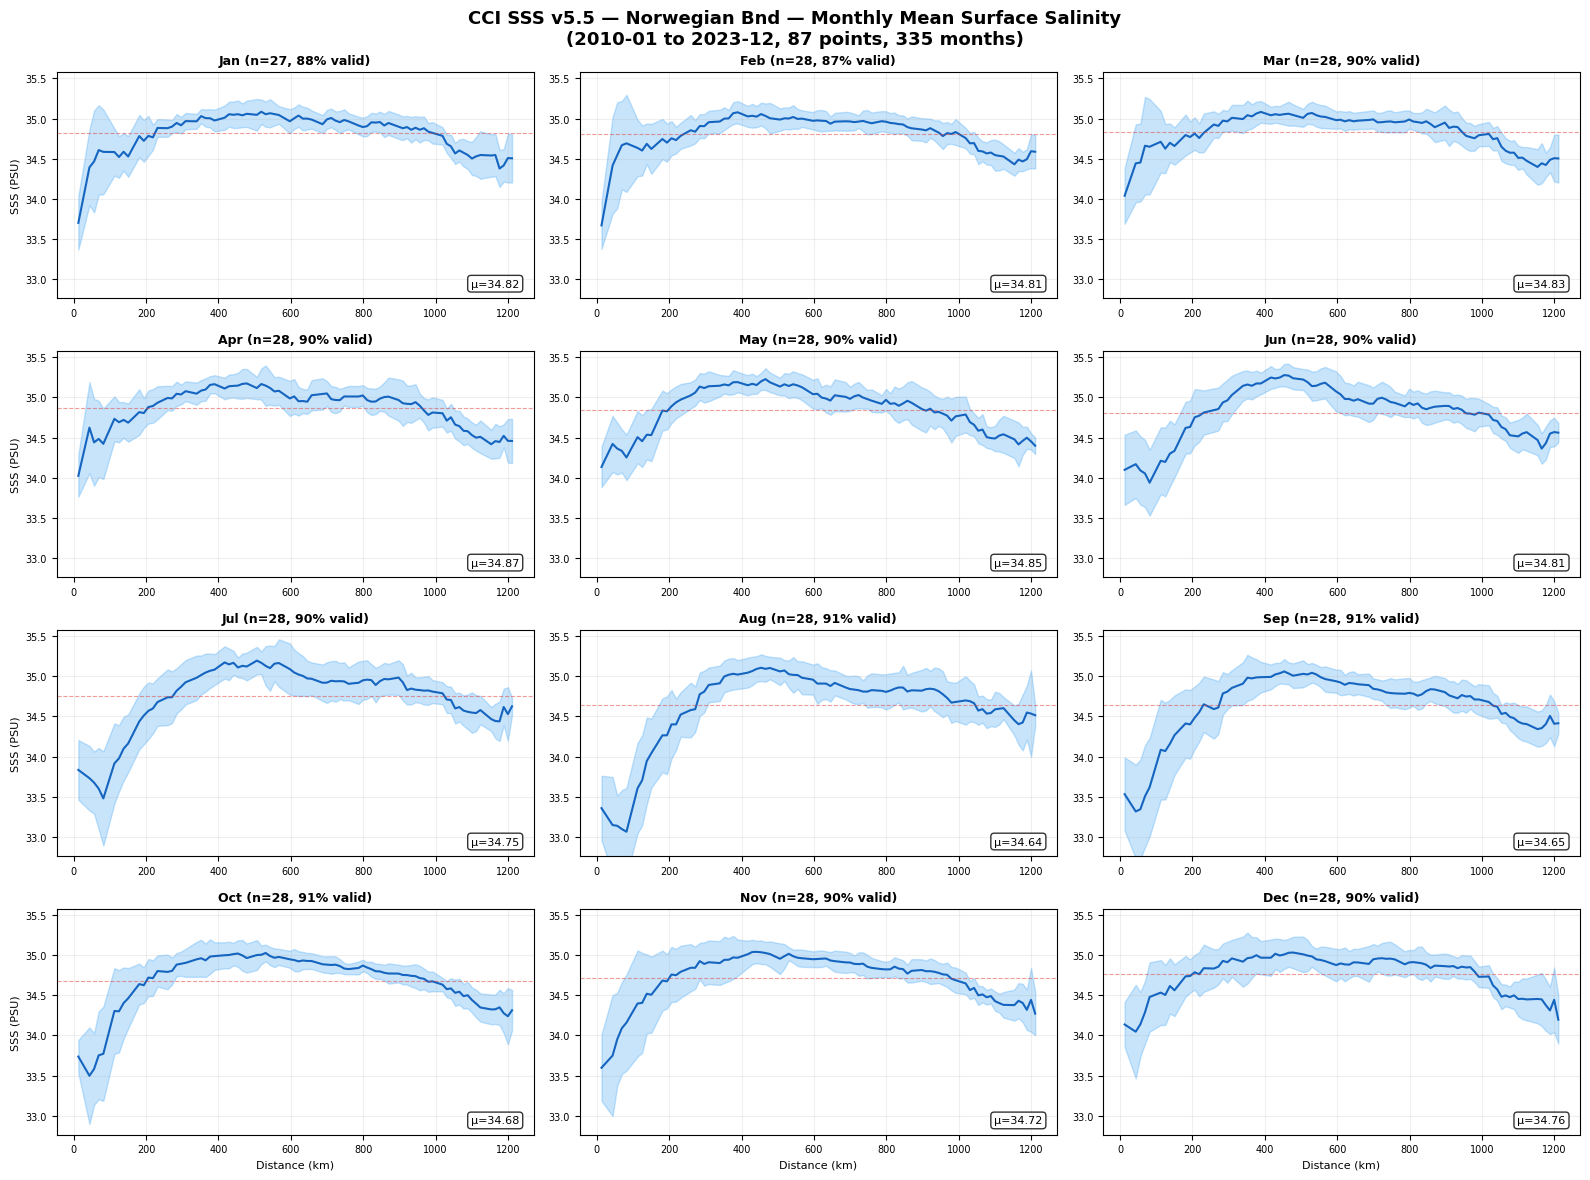

/var/folders/q5/g4rsymgj6137bp73lx06r3g40000gn/T/ipykernel_54350/3863956913.py:53: RuntimeWarning: Mean of empty slice
  monthly = np.nanmean(sss[mask, :], axis=0)
/var/folders/q5/g4rsymgj6137bp73lx06r3g40000gn/T/ipykernel_54350/3863956913.py:53: RuntimeWarning: Mean of empty slice
  monthly = np.nanmean(sss[mask, :], axis=0)
/var/folders/q5/g4rsymgj6137bp73lx06r3g40000gn/T/ipykernel_54350/3863956913.py:53: RuntimeWarning: Mean of empty slice
  monthly = np.nanmean(sss[mask, :], axis=0)
/var/folders/q5/g4rsymgj6137bp73lx06r3g40000gn/T/ipykernel_54350/3863956913.py:53: RuntimeWarning: Mean of empty slice
  monthly = np.nanmean(sss[mask, :], axis=0)
/var/folders/q5/g4rsymgj6137bp73lx06r3g40000gn/T/ipykernel_54350/3863956913.py:53: RuntimeWarning: Mean of empty slice
  monthly = np.nanmean(sss[mask, :], axis=0)
/var/folders/q5/g4rsymgj6137bp73lx06r3g40000gn/T/ipykernel_54350/3863956913.py:53: RuntimeWarning: Mean of empty slice
  monthly = np.nanmean(sss[mask, :], axis=0)
/var/folders/q5/

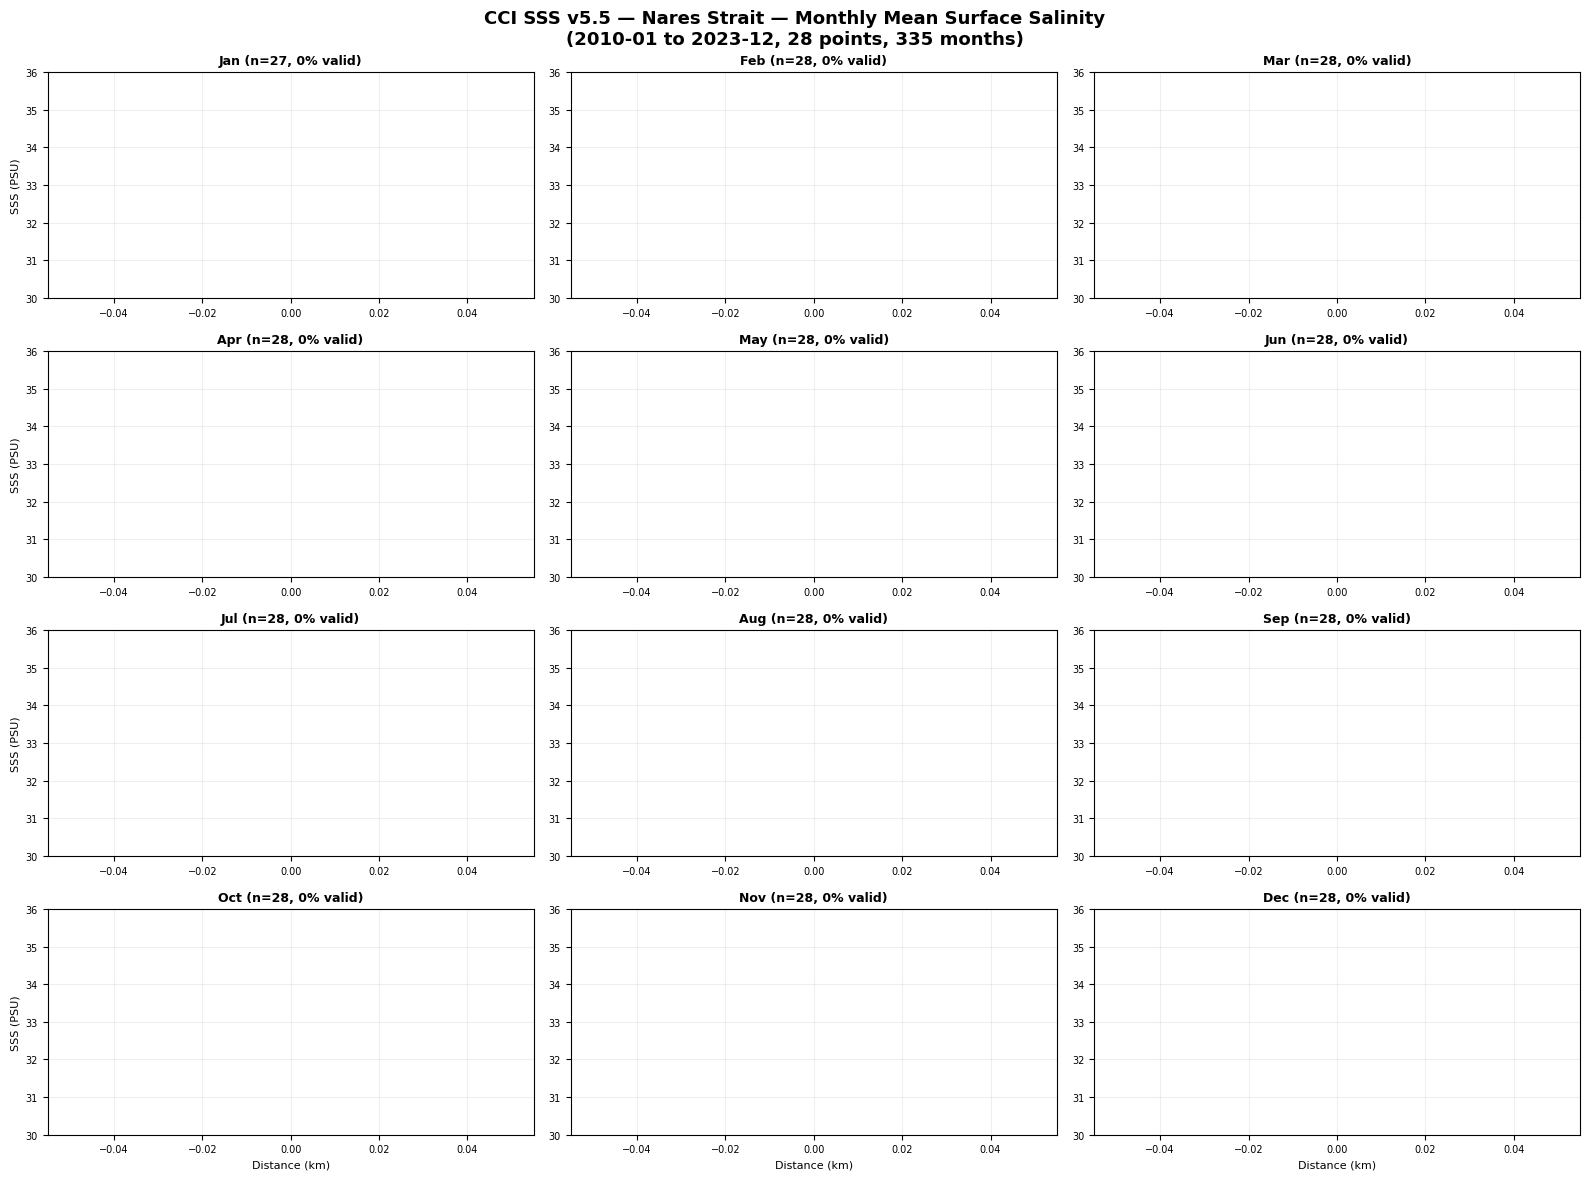

In [ ]:
# ═══════════════════════════════════════════════════════════════
# 2. CCI SSS v5.5 — Monthly Climatology Profiles (4×3) per gate
# ═══════════════════════════════════════════════════════════════
# Per ogni gate: media mensile della SSS lungo il profilo (solo superficie)

import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

NC = Path("/Users/nicolocaron/Desktop/ARCFRESH/straits/netcdf")
MONTH_NAMES = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

GATES = {
    "Fram Strait":     "fram_strait_S3_pass_481",
    "Denmark Strait":  "denmark_strait_TPJ_pass_246",
    "Davis Strait":    "davis_strait",
    "Bering Strait":   "bering_strait_TPJ_pass_076",
    "Barents Opening": "barents_sea_opening_S3_pass_481",
    "Norwegian Bnd":   "norwegian_sea_boundary_TPJ_pass_220",
    "Nares Strait":    "nares_strait",
}

for gate_name, prefix in GATES.items():
    ds = xr.open_dataset(NC / f"{prefix}_SSS_CCIv5.5.nc")
    dates = pd.to_datetime(ds['date'].values)
    sss = ds['sss'].values       # (time, nb_prof)
    lon = ds['longitude'].values  # (nb_prof,)
    lat = ds['latitude'].values   # (nb_prof,)
    ds.close()
    
    # Compute along-gate distance (km)
    dist = np.zeros(len(lon))
    for i in range(1, len(lon)):
        dlat = lat[i] - lat[i-1]
        dlon = (lon[i] - lon[i-1]) * np.cos(np.deg2rad((lat[i]+lat[i-1])/2))
        dist[i] = dist[i-1] + np.sqrt(dlat**2 + dlon**2) * 111.32
    
    # Figure
    fig, axes = plt.subplots(4, 3, figsize=(16, 12))
    fig.suptitle(f"CCI SSS v5.5 — {gate_name} — Monthly Mean Surface Salinity\n"
                 f"({dates[0].strftime('%Y-%m')} to {dates[-1].strftime('%Y-%m')}, "
                 f"{len(lon)} points, {len(dates)} months)",
                 fontsize=13, fontweight='bold')
    
    # Global y-range
    all_means = []
    for m in range(1, 13):
        mask = dates.month == m
        if mask.sum() > 0:
            monthly = np.nanmean(sss[mask, :], axis=0)
            all_means.append(monthly)
    if all_means:
        all_vals = np.concatenate(all_means)
        ymin = np.nanmin(all_vals) - 0.3
        ymax = np.nanmax(all_vals) + 0.3
        if np.isnan(ymin): ymin, ymax = 30, 36
    else:
        ymin, ymax = 30, 36
    
    for m in range(1, 13):
        row, col = (m-1)//3, (m-1)%3
        ax = axes[row, col]
        
        mask = dates.month == m
        n_months = mask.sum()
        
        if n_months == 0:
            ax.text(0.5, 0.5, "No data", ha='center', va='center', transform=ax.transAxes)
            ax.set_title(MONTH_NAMES[m-1], fontweight='bold')
            continue
        
        monthly_sss = sss[mask, :]  # (n_years_for_this_month, nb_prof)
        mean_profile = np.nanmean(monthly_sss, axis=0)
        std_profile = np.nanstd(monthly_sss, axis=0)
        
        valid_pct = (~np.isnan(monthly_sss)).sum() / monthly_sss.size * 100
        
        ax.fill_between(dist, mean_profile - std_profile, mean_profile + std_profile,
                        alpha=0.25, color='#2196F3')
        ax.plot(dist, mean_profile, color='#1565C0', linewidth=1.5)
        ax.axhline(np.nanmean(mean_profile), color='#E53935', linewidth=0.8, linestyle='--', alpha=0.5)
        
        ax.set_ylim(ymin, ymax)
        ax.set_title(f"{MONTH_NAMES[m-1]} (n={n_months}, {valid_pct:.0f}% valid)", fontsize=9, fontweight='bold')
        ax.grid(True, alpha=0.2)
        
        # Mean annotation
        gate_mean = np.nanmean(mean_profile)
        if not np.isnan(gate_mean):
            ax.text(0.97, 0.05, f"μ={gate_mean:.2f}", transform=ax.transAxes,
                    fontsize=8, ha='right', bbox=dict(boxstyle='round', fc='white', alpha=0.8))
        
        if col == 0: ax.set_ylabel("SSS (PSU)", fontsize=8)
        if row == 3: ax.set_xlabel("Distance (km)", fontsize=8)
        ax.tick_params(labelsize=7)
    
    plt.tight_layout()
    plt.show()
    print()


/var/folders/q5/g4rsymgj6137bp73lx06r3g40000gn/T/ipykernel_54350/3380139284.py:69: RuntimeWarning: Mean of empty slice
  avg_50m = np.nanmean(psal[m, z_mask_50, :], axis=0)


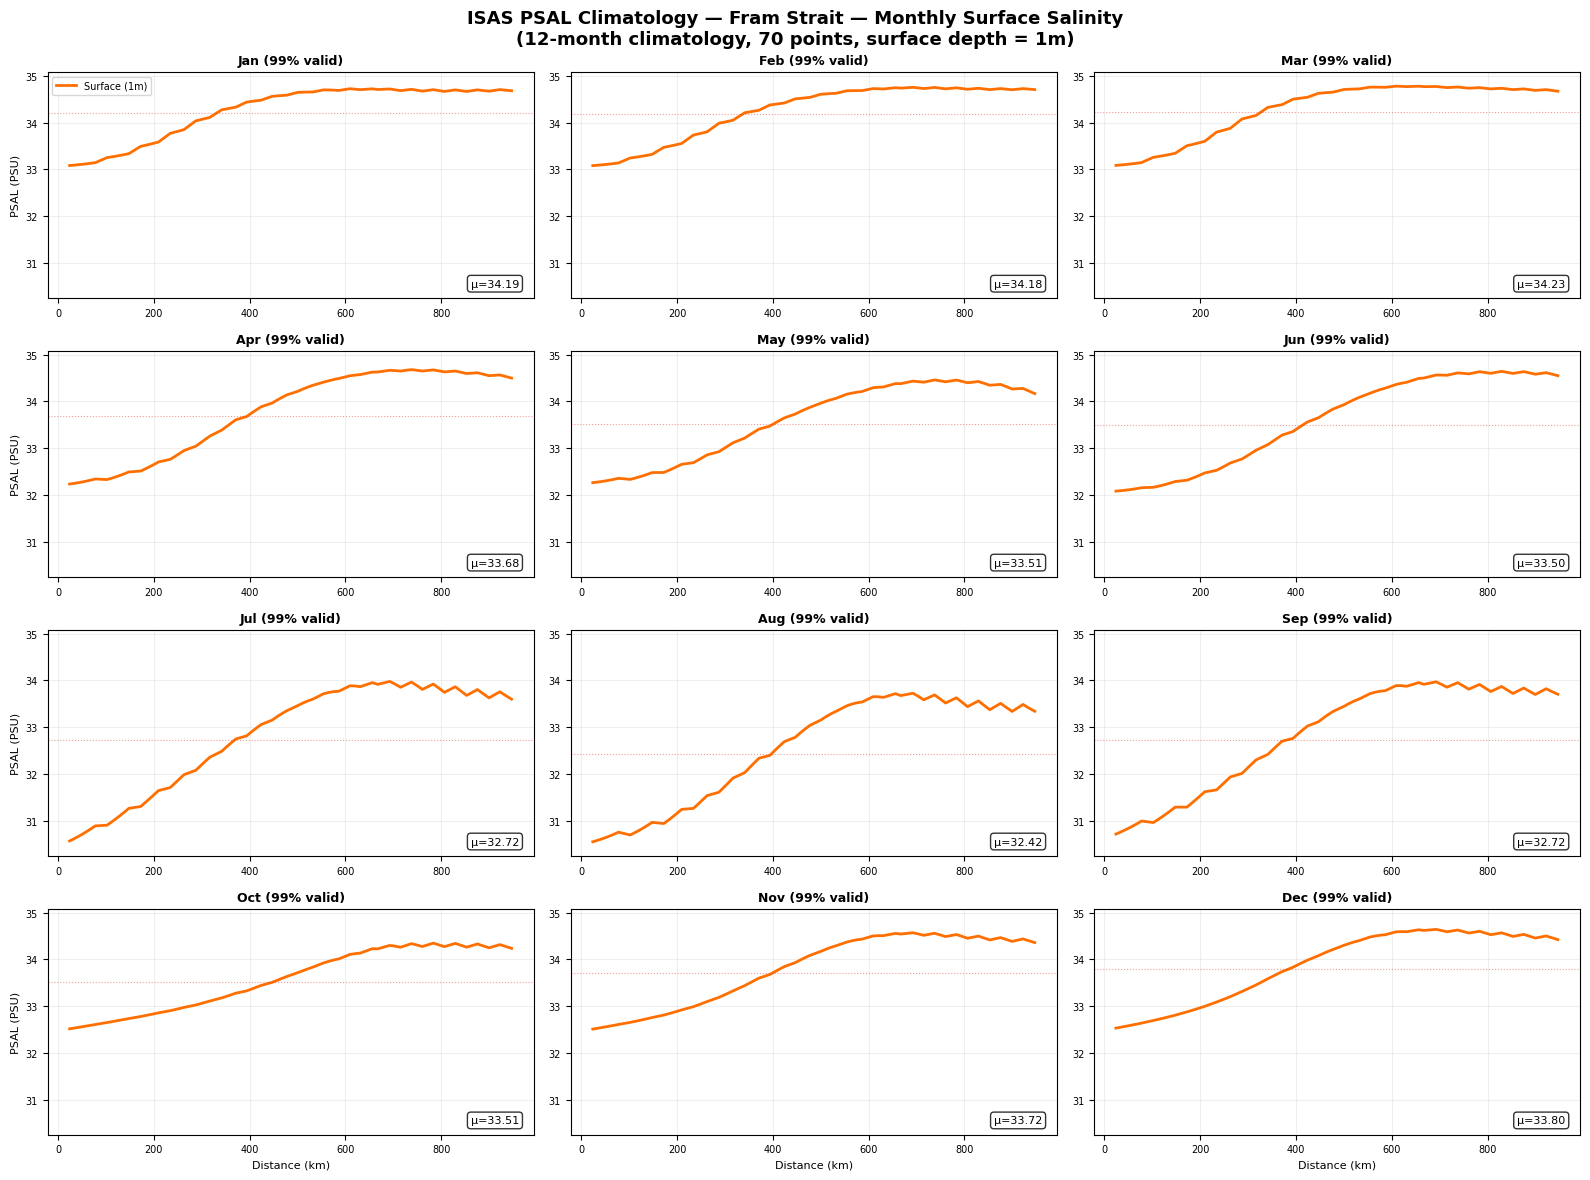

  Fram Strait: CCI mean=34.60 PSU, ISAS surface mean=33.51 PSU, Δ=+1.09 PSU



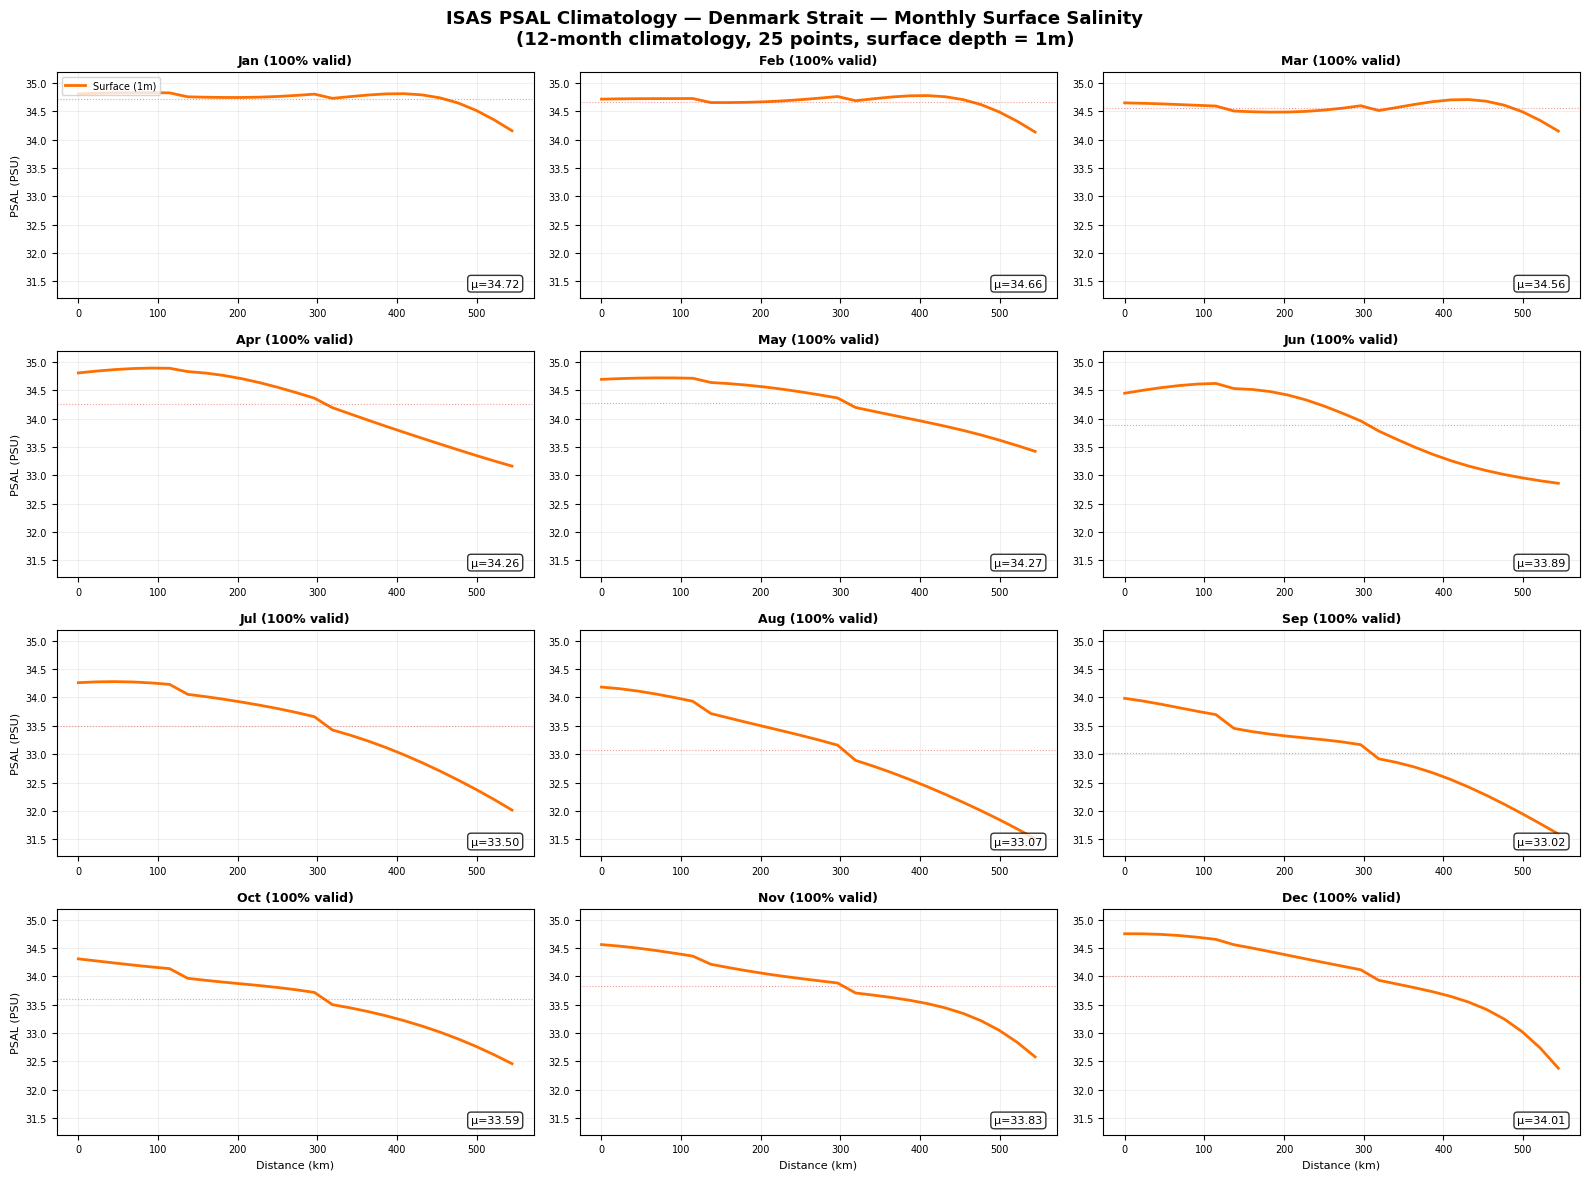

  Denmark Strait: CCI mean=34.44 PSU, ISAS surface mean=33.95 PSU, Δ=+0.49 PSU



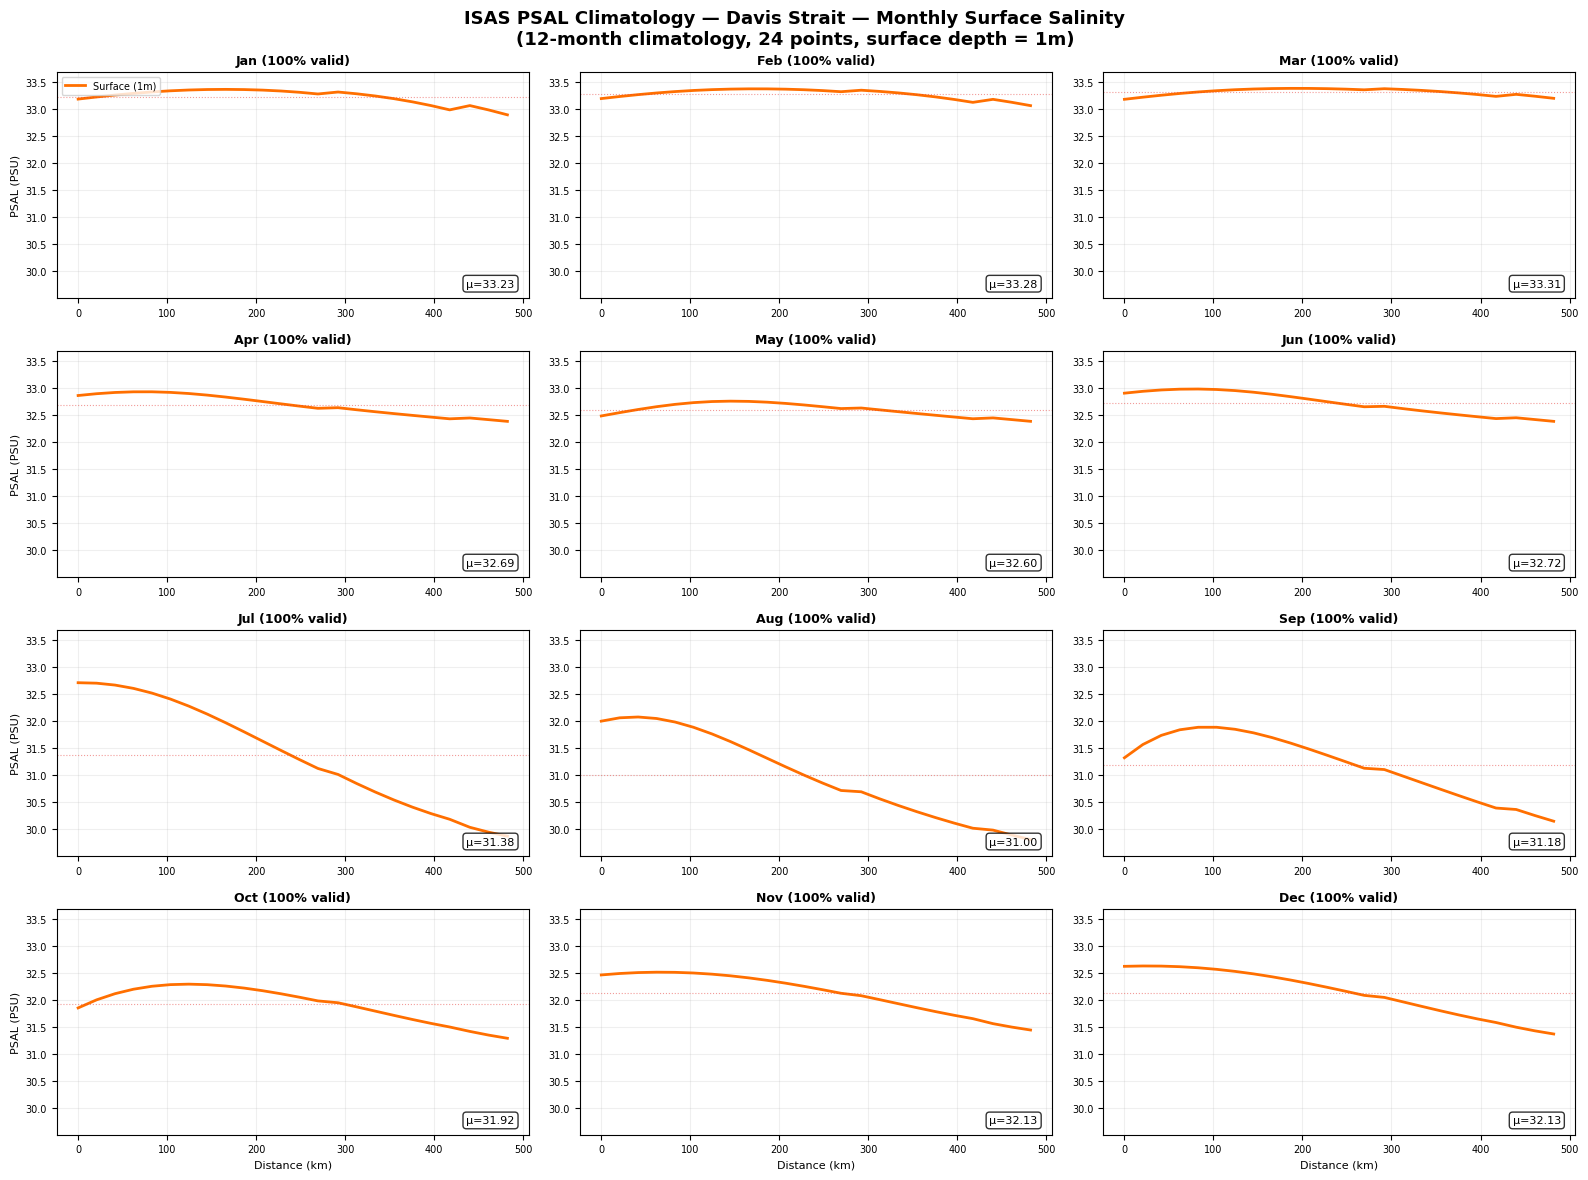

  Davis Strait: CCI mean=31.97 PSU, ISAS surface mean=32.30 PSU, Δ=-0.33 PSU



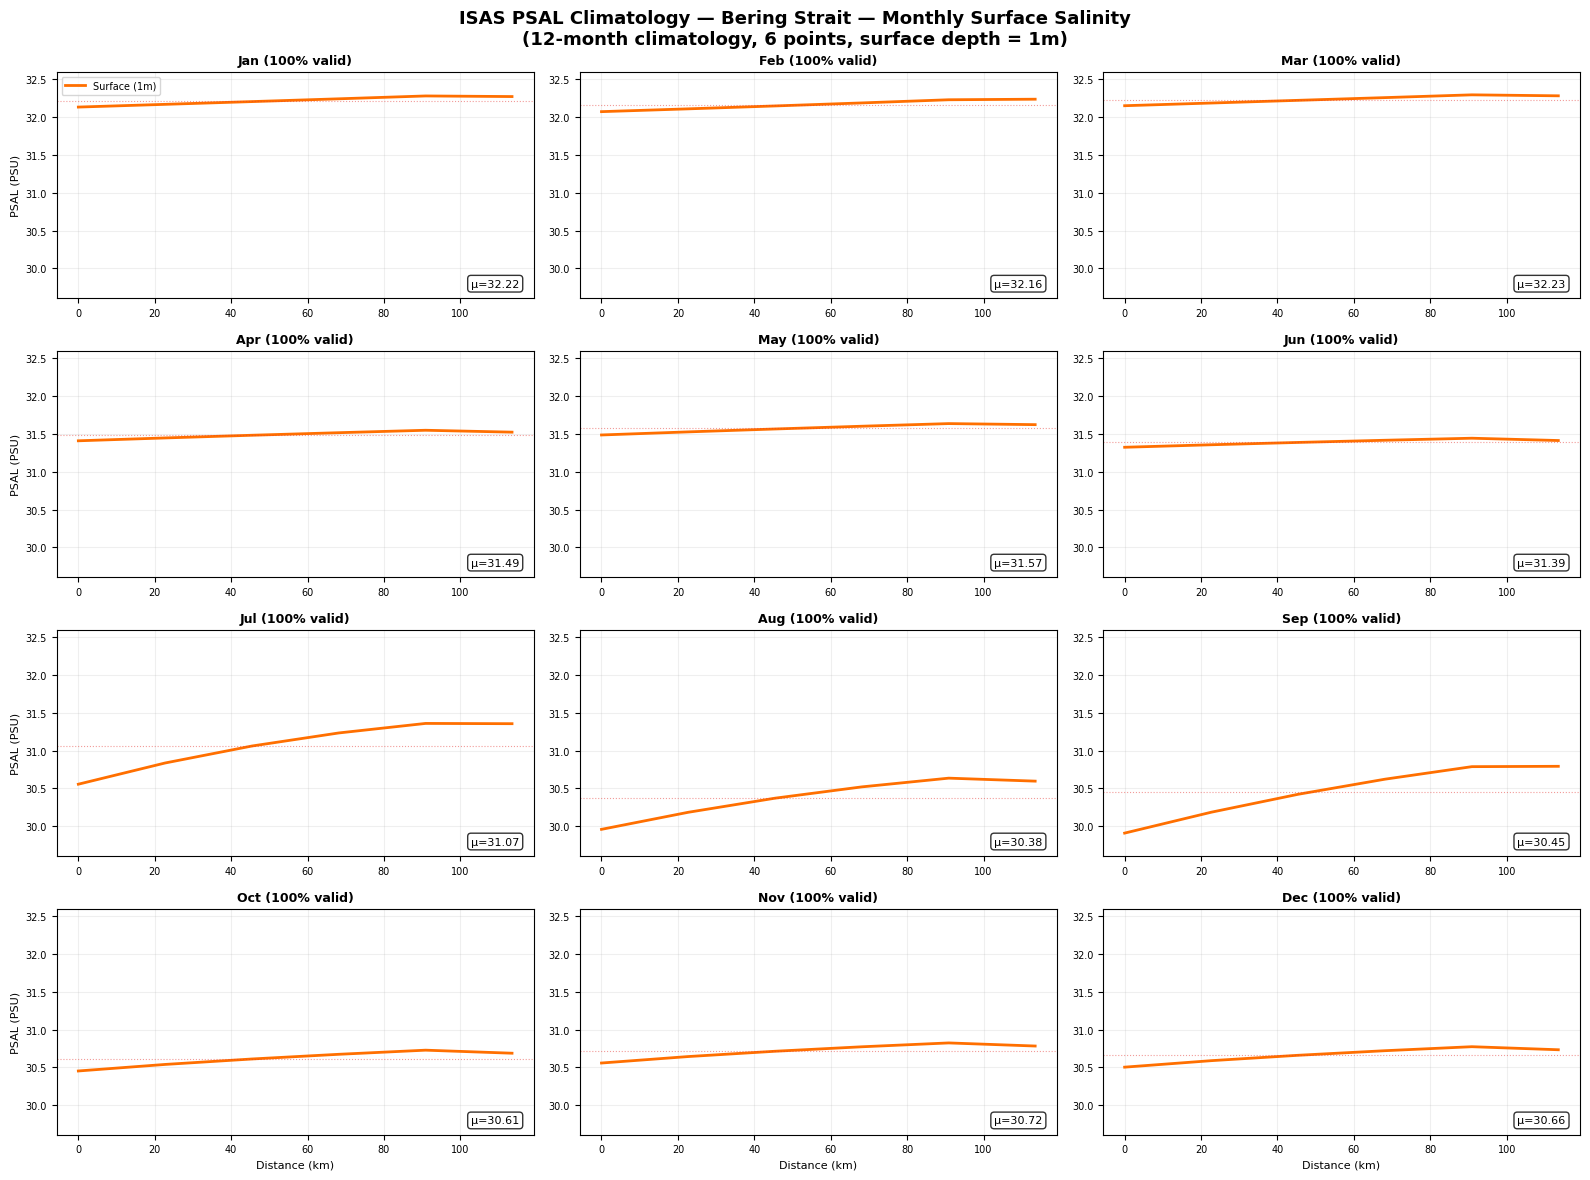

  Bering Strait: CCI mean=32.14 PSU, ISAS surface mean=31.25 PSU, Δ=+0.90 PSU



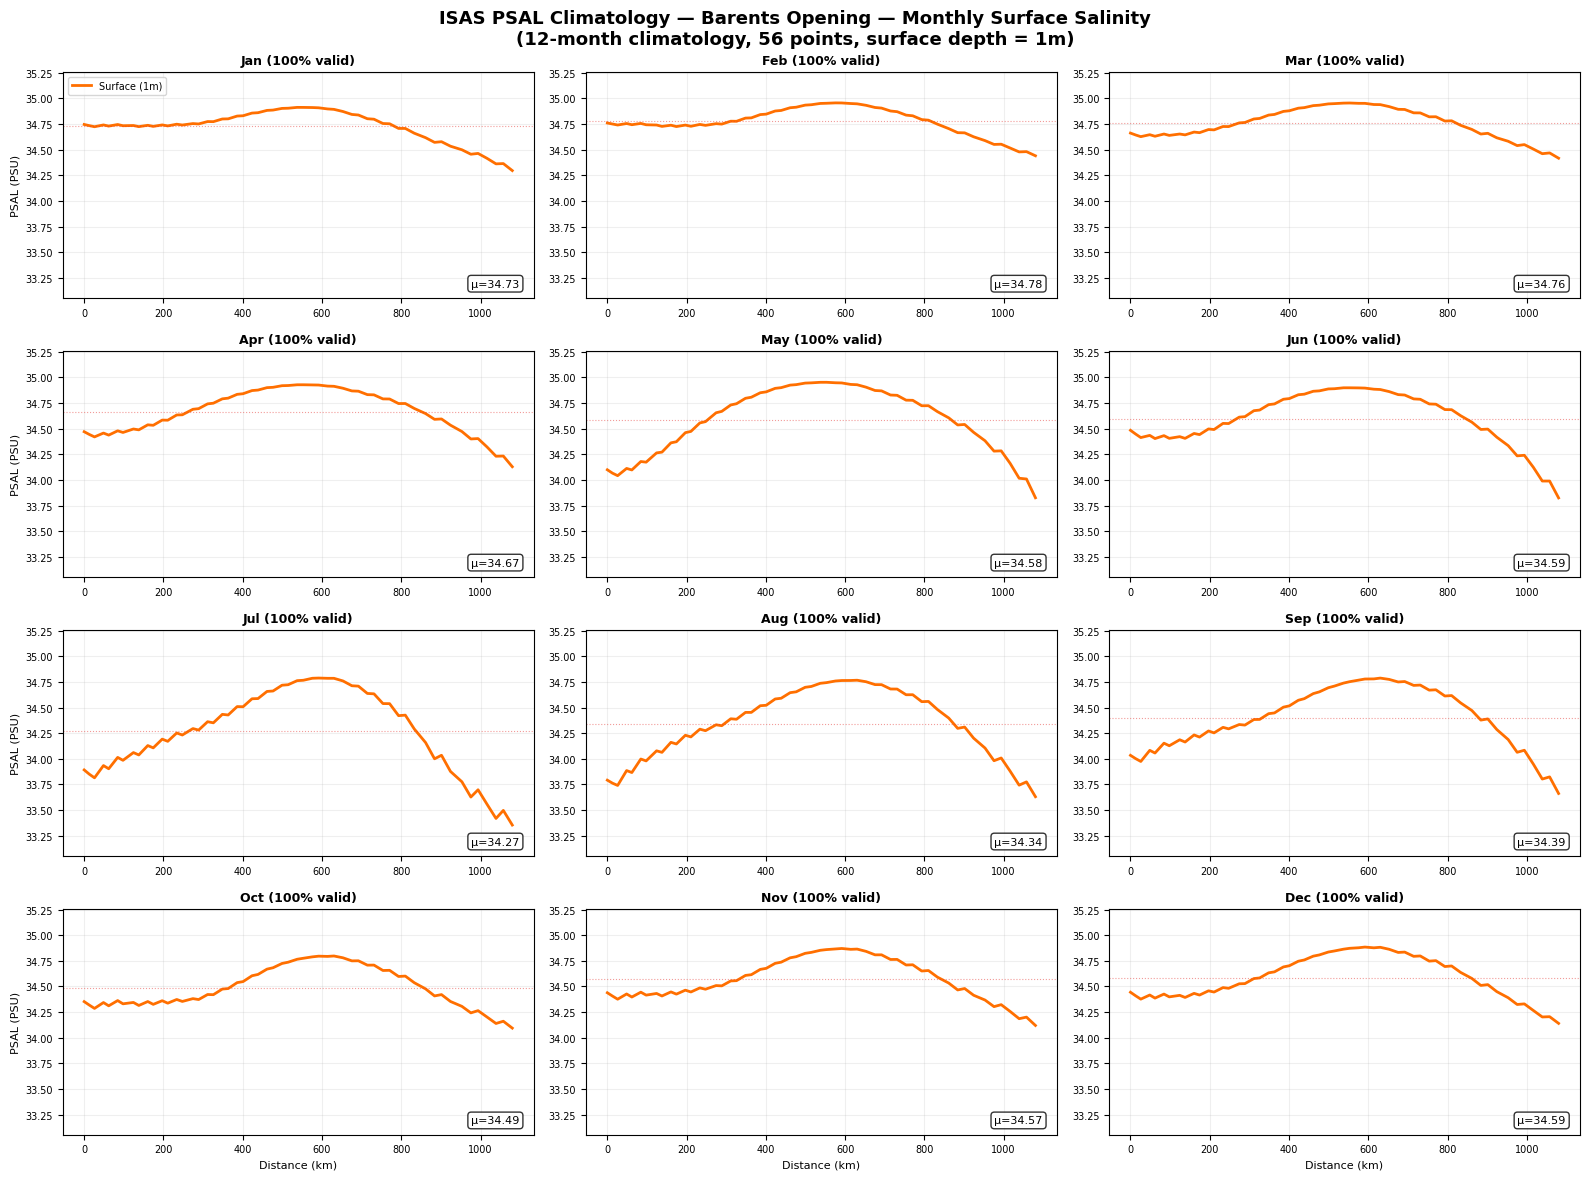

  Barents Opening: CCI mean=34.74 PSU, ISAS surface mean=34.56 PSU, Δ=+0.18 PSU



/var/folders/q5/g4rsymgj6137bp73lx06r3g40000gn/T/ipykernel_54350/3380139284.py:69: RuntimeWarning: Mean of empty slice
  avg_50m = np.nanmean(psal[m, z_mask_50, :], axis=0)


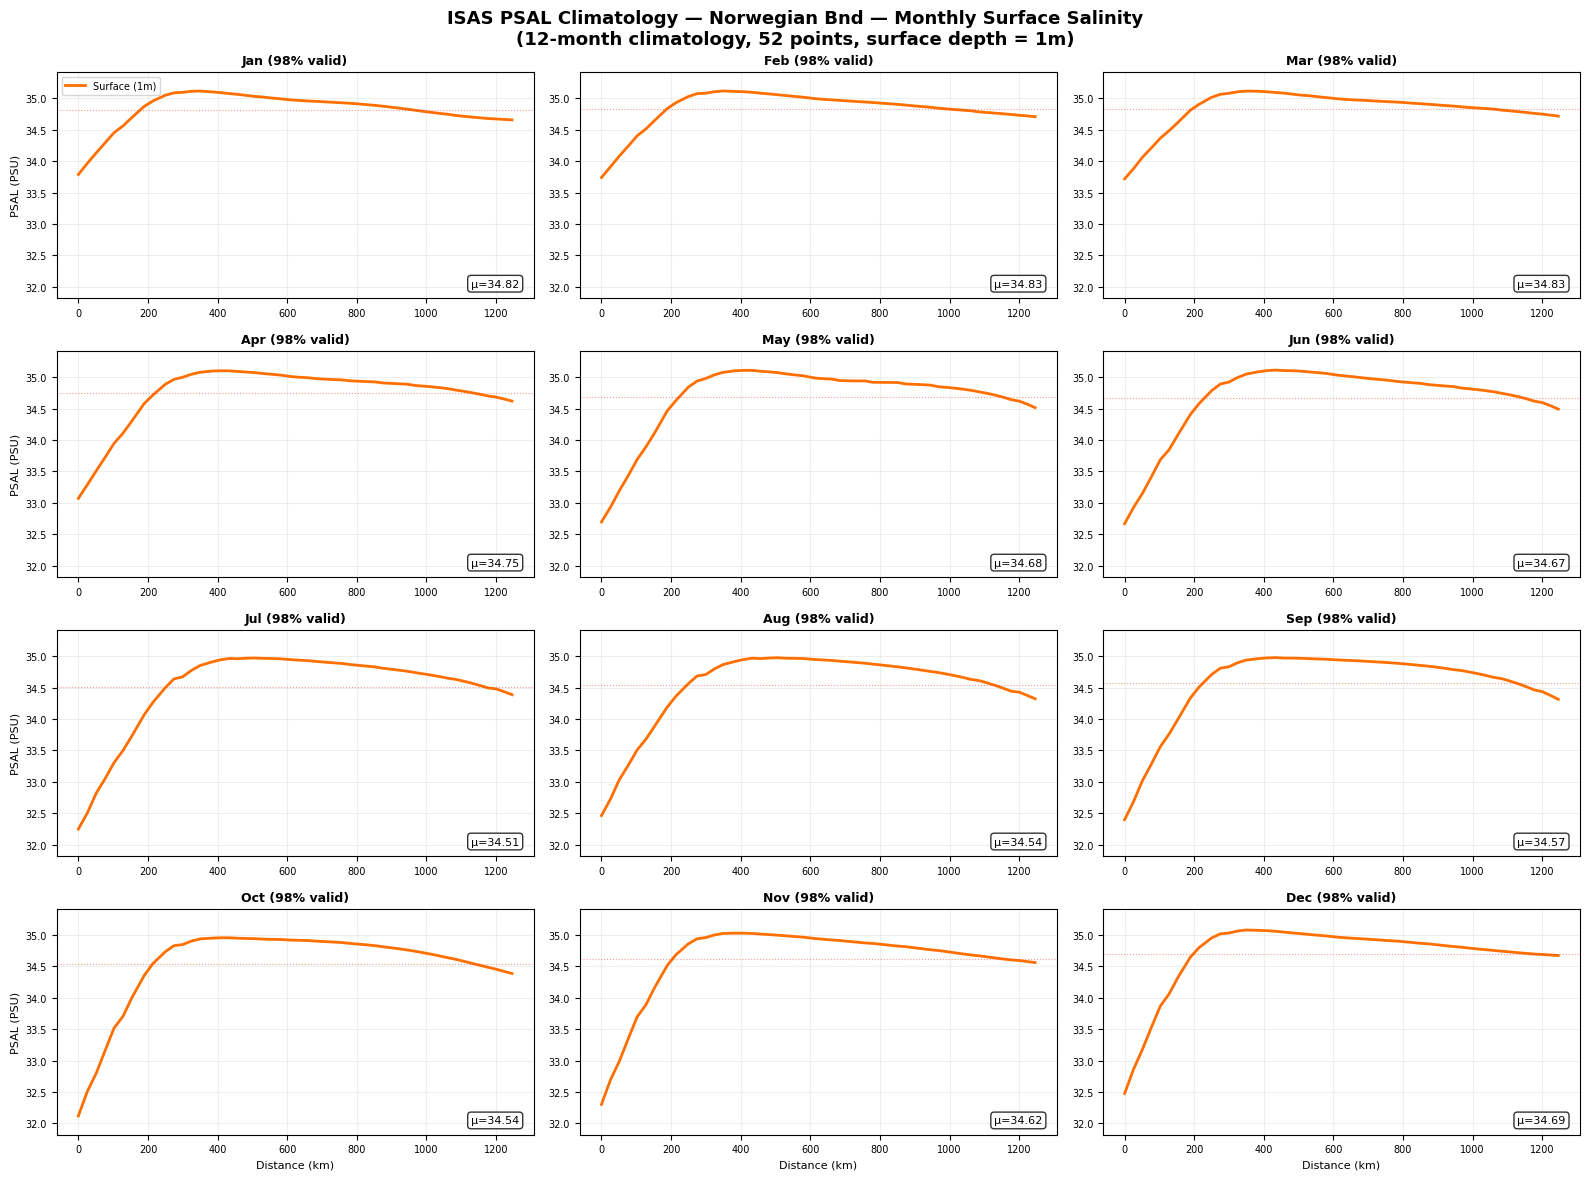

  Norwegian Bnd: CCI mean=34.78 PSU, ISAS surface mean=34.67 PSU, Δ=+0.11 PSU



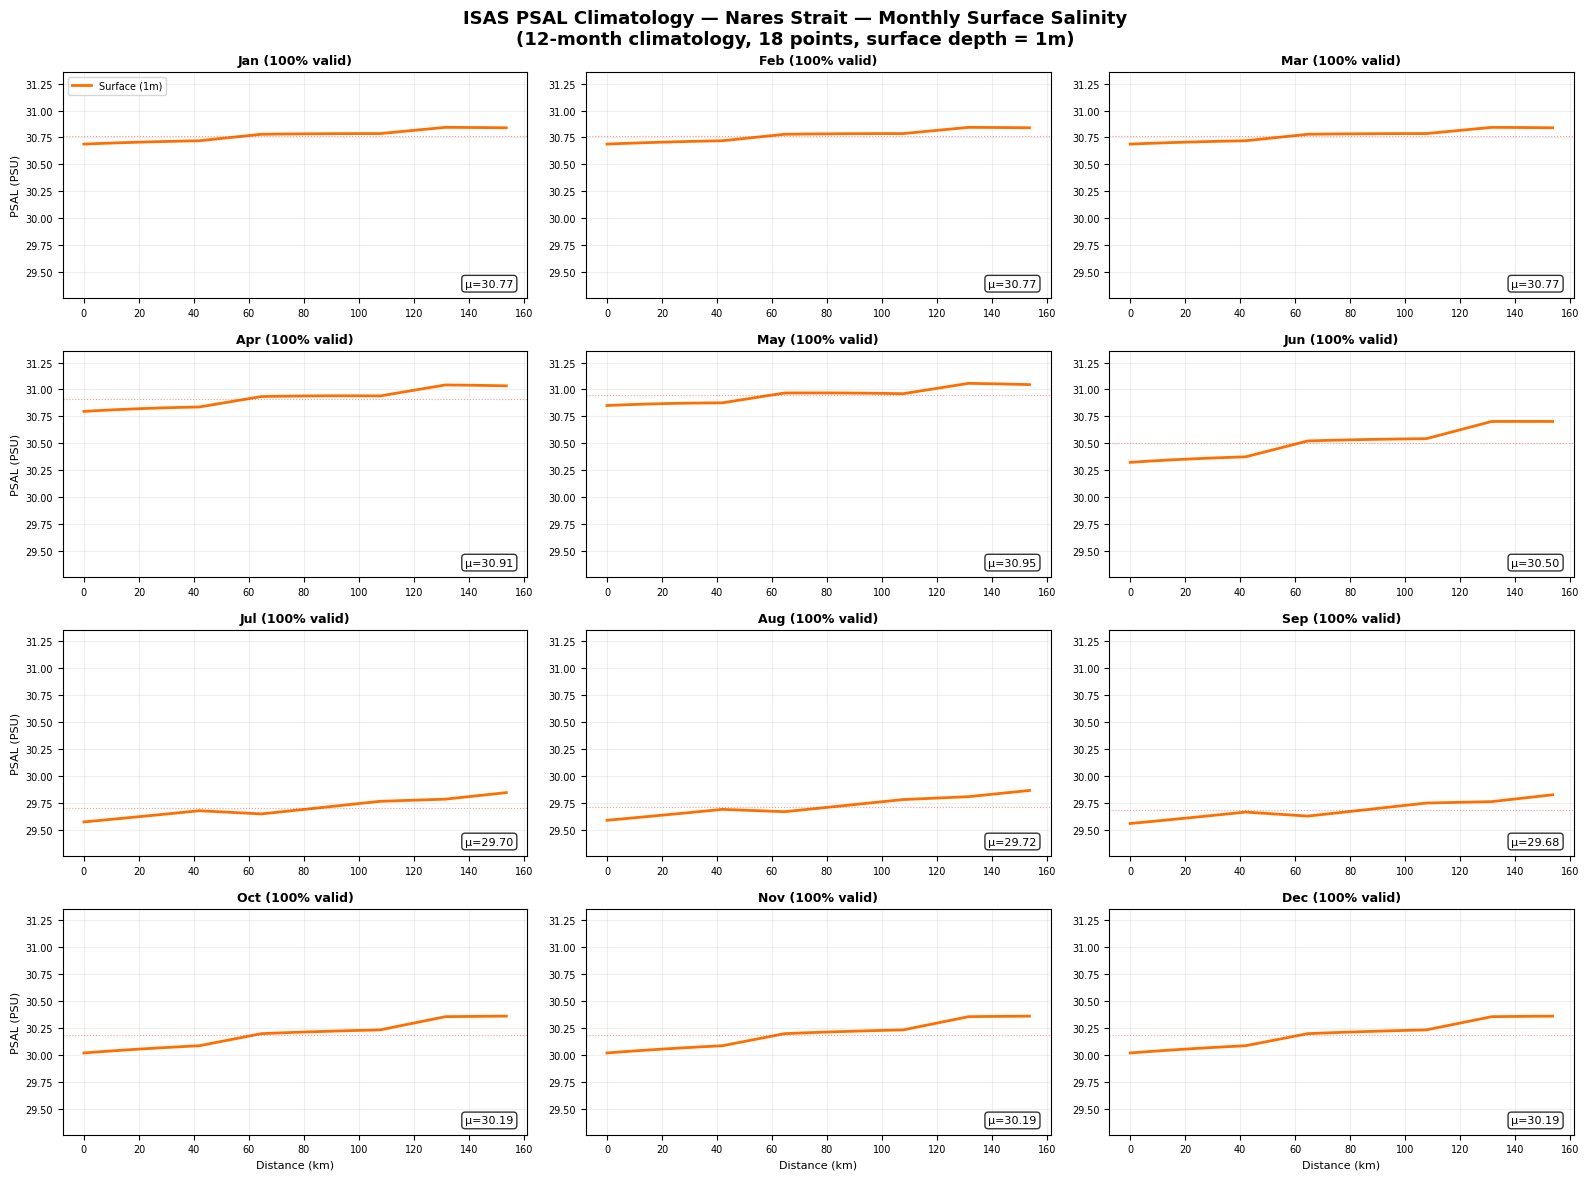

  Nares Strait: CCI mean=nan PSU, ISAS surface mean=30.36 PSU, Δ=+nan PSU



/var/folders/q5/g4rsymgj6137bp73lx06r3g40000gn/T/ipykernel_54350/3380139284.py:95: RuntimeWarning: Mean of empty slice
  cci_mean = np.nanmean(cci_ds['sss'].values)


In [ ]:
# ═══════════════════════════════════════════════════════════════
# 3. ISAS PSAL Climatology — Monthly Surface Profiles (4×3) per gate
# ═══════════════════════════════════════════════════════════════
# ISAS ha 12 mesi di climatologia + 187 livelli di profondità.
# Plottiamo solo lo strato superficiale (z=0, ~0-5m).
#
# ── SET SAVE_OUTPUT = True TO EXPORT FIGURES + DATA ──────────
# Creates 3 folders under OUTPUT_DIR:
#   1) comparison/   — CCI vs ISAS comparison (summary stats CSV)
#   2) cci_profiles/ — CCI SSS monthly profile figures + CSV
#   3) isas_profiles/ — ISAS PSAL monthly profile figures + CSV

import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ─── Configuration ────────────────────────────────────────────
SAVE_OUTPUT = True  # ← Toggle this to enable/disable saving
OUTPUT_DIR = Path("/Users/nicolocaron/Documents/GitHub/ARCFRESH-DTU-NICO-and-AMALIE/data/salinity_analysis")

NC = Path("/Users/nicolocaron/Desktop/ARCFRESH/straits/netcdf")
MONTH_NAMES = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

GATES = {
    "Fram Strait":     "fram_strait_S3_pass_481",
    "Denmark Strait":  "denmark_strait_TPJ_pass_246",
    "Davis Strait":    "davis_strait",
    "Bering Strait":   "bering_strait_TPJ_pass_076",
    "Barents Opening": "barents_sea_opening_S3_pass_481",
    "Norwegian Bnd":   "norwegian_sea_boundary_TPJ_pass_220",
    "Nares Strait":    "nares_strait",
}

# ─── Create output directories if saving ─────────────────────
if SAVE_OUTPUT:
    dir_comparison  = OUTPUT_DIR / "comparison"
    dir_cci         = OUTPUT_DIR / "cci_profiles"
    dir_isas        = OUTPUT_DIR / "isas_profiles"
    for d in [dir_comparison, dir_cci, dir_isas]:
        d.mkdir(parents=True, exist_ok=True)
    print(f"📁 Output directories created under: {OUTPUT_DIR}")

# ─── Collect comparison data ──────────────────────────────────
comparison_rows = []

for gate_name, prefix in GATES.items():
    safe_name = gate_name.lower().replace(' ', '_').replace('.', '')

    # ═══════════════════════════════════════════════════════════
    # A) ISAS PSAL — Monthly Surface Profiles
    # ═══════════════════════════════════════════════════════════
    ds = xr.open_dataset(NC / f"{prefix}_CLIM_ISAS_PSAL.nc")
    dates = pd.to_datetime(ds['date'].values)
    psal = ds['PSAL'].values       # (time=12, z=187, nb_prof)
    depth = ds['depth'].values     # (z=187,)
    lon = ds['longitude'].values   # (nb_prof,)
    lat = ds['latitude'].values    # (nb_prof,)
    ds.close()
    
    surf_idx = 0
    surf_depth = depth[surf_idx]
    
    # Along-gate distance (km)
    dist = np.zeros(len(lon))
    for i in range(1, len(lon)):
        dlat = lat[i] - lat[i-1]
        dlon = (lon[i] - lon[i-1]) * np.cos(np.deg2rad((lat[i]+lat[i-1])/2))
        dist[i] = dist[i-1] + np.sqrt(dlat**2 + dlon**2) * 111.32
    
    # Figure — ISAS
    fig, axes = plt.subplots(4, 3, figsize=(16, 12))
    fig.suptitle(f"ISAS PSAL Climatology — {gate_name} — Monthly Surface Salinity\n"
                 f"(12-month climatology, {len(lon)} points, surface depth = {surf_depth:.0f}m)",
                 fontsize=13, fontweight='bold')
    
    surf_all = psal[:, surf_idx, :]  # (12, nb_prof)
    ymin = np.nanmin(surf_all) - 0.3
    ymax = np.nanmax(surf_all) + 0.3
    if np.isnan(ymin): ymin, ymax = 30, 36

    # CSV data for ISAS
    isas_csv_data = {'distance_km': dist}
    
    for m in range(12):
        row, col = m//3, m%3
        ax = axes[row, col]
        
        surf_profile = psal[m, surf_idx, :]
        valid_surf = (~np.isnan(surf_profile)).sum() / len(surf_profile) * 100
        
        ax.plot(dist, surf_profile, color='#FF6F00', linewidth=2, label=f'Surface ({surf_depth:.0f}m)')
        ax.axhline(np.nanmean(surf_profile), color='#E53935', linewidth=0.8, linestyle=':', alpha=0.5)
        
        ax.set_ylim(ymin, ymax)
        ax.set_title(f"{MONTH_NAMES[m]} ({valid_surf:.0f}% valid)", fontsize=9, fontweight='bold')
        ax.grid(True, alpha=0.2)
        
        gate_mean = np.nanmean(surf_profile)
        if not np.isnan(gate_mean):
            ax.text(0.97, 0.05, f"μ={gate_mean:.2f}", transform=ax.transAxes,
                    fontsize=8, ha='right', bbox=dict(boxstyle='round', fc='white', alpha=0.8))
        
        if col == 0: ax.set_ylabel("PSAL (PSU)", fontsize=8)
        if row == 3: ax.set_xlabel("Distance (km)", fontsize=8)
        ax.tick_params(labelsize=7)
        if m == 0: ax.legend(fontsize=7, loc='upper left')

        isas_csv_data[f'{MONTH_NAMES[m]}_surface'] = surf_profile
    
    plt.tight_layout()
    
    if SAVE_OUTPUT:
        fig.savefig(dir_isas / f"{safe_name}_isas_psal_monthly.png", dpi=150, bbox_inches='tight')
        pd.DataFrame(isas_csv_data).to_csv(dir_isas / f"{safe_name}_isas_psal_monthly.csv", index=False)
    
    plt.show()

    # ═══════════════════════════════════════════════════════════
    # B) CCI SSS v5.5 — Monthly Mean Profiles (from Cell 2 logic)
    # ═══════════════════════════════════════════════════════════
    ds_cci = xr.open_dataset(NC / f"{prefix}_SSS_CCIv5.5.nc")
    cci_dates = pd.to_datetime(ds_cci['date'].values)
    cci_sss = ds_cci['sss'].values       # (time, nb_prof)
    cci_lon = ds_cci['longitude'].values
    cci_lat = ds_cci['latitude'].values
    ds_cci.close()

    # CCI along-gate distance
    cci_dist = np.zeros(len(cci_lon))
    for i in range(1, len(cci_lon)):
        dlat = cci_lat[i] - cci_lat[i-1]
        dlon = (cci_lon[i] - cci_lon[i-1]) * np.cos(np.deg2rad((cci_lat[i]+cci_lat[i-1])/2))
        cci_dist[i] = cci_dist[i-1] + np.sqrt(dlat**2 + dlon**2) * 111.32

    fig2, axes2 = plt.subplots(4, 3, figsize=(16, 12))
    fig2.suptitle(f"CCI SSS v5.5 — {gate_name} — Monthly Mean Surface Salinity\n"
                  f"({cci_dates[0].strftime('%Y-%m')} to {cci_dates[-1].strftime('%Y-%m')}, "
                  f"{len(cci_lon)} points, {len(cci_dates)} months)",
                  fontsize=13, fontweight='bold')

    cci_all_means = []
    for m in range(1, 13):
        mask = cci_dates.month == m
        if mask.sum() > 0:
            cci_all_means.append(np.nanmean(cci_sss[mask, :], axis=0))
    if cci_all_means:
        cci_all_vals = np.concatenate(cci_all_means)
        cci_ymin = np.nanmin(cci_all_vals) - 0.3
        cci_ymax = np.nanmax(cci_all_vals) + 0.3
        if np.isnan(cci_ymin): cci_ymin, cci_ymax = 30, 36
    else:
        cci_ymin, cci_ymax = 30, 36

    cci_csv_data = {'distance_km': cci_dist}

    for m in range(1, 13):
        row, col = (m-1)//3, (m-1)%3
        ax = axes2[row, col]
        mask = cci_dates.month == m
        n_months = mask.sum()

        if n_months == 0:
            ax.text(0.5, 0.5, "No data", ha='center', va='center', transform=ax.transAxes)
            ax.set_title(MONTH_NAMES[m-1], fontweight='bold')
            cci_csv_data[f'{MONTH_NAMES[m-1]}_mean'] = np.full(len(cci_lon), np.nan)
            cci_csv_data[f'{MONTH_NAMES[m-1]}_std'] = np.full(len(cci_lon), np.nan)
            continue

        monthly_sss = cci_sss[mask, :]
        mean_profile = np.nanmean(monthly_sss, axis=0)
        std_profile = np.nanstd(monthly_sss, axis=0)
        valid_pct = (~np.isnan(monthly_sss)).sum() / monthly_sss.size * 100

        ax.fill_between(cci_dist, mean_profile - std_profile, mean_profile + std_profile,
                        alpha=0.25, color='#2196F3')
        ax.plot(cci_dist, mean_profile, color='#1565C0', linewidth=1.5)
        ax.axhline(np.nanmean(mean_profile), color='#E53935', linewidth=0.8, linestyle='--', alpha=0.5)
        ax.set_ylim(cci_ymin, cci_ymax)
        ax.set_title(f"{MONTH_NAMES[m-1]} (n={n_months}, {valid_pct:.0f}% valid)", fontsize=9, fontweight='bold')
        ax.grid(True, alpha=0.2)

        gate_mean = np.nanmean(mean_profile)
        if not np.isnan(gate_mean):
            ax.text(0.97, 0.05, f"μ={gate_mean:.2f}", transform=ax.transAxes,
                    fontsize=8, ha='right', bbox=dict(boxstyle='round', fc='white', alpha=0.8))
        if col == 0: ax.set_ylabel("SSS (PSU)", fontsize=8)
        if row == 3: ax.set_xlabel("Distance (km)", fontsize=8)
        ax.tick_params(labelsize=7)

        cci_csv_data[f'{MONTH_NAMES[m-1]}_mean'] = mean_profile
        cci_csv_data[f'{MONTH_NAMES[m-1]}_std'] = std_profile

    plt.tight_layout()

    if SAVE_OUTPUT:
        fig2.savefig(dir_cci / f"{safe_name}_cci_sss_monthly.png", dpi=150, bbox_inches='tight')
        pd.DataFrame(cci_csv_data).to_csv(dir_cci / f"{safe_name}_cci_sss_monthly.csv", index=False)

    plt.show()

    # ═══════════════════════════════════════════════════════════
    # C) Comparison stats for this gate
    # ═══════════════════════════════════════════════════════════
    cci_mean = np.nanmean(cci_sss)
    isas_surf_mean = np.nanmean(surf_all)
    diff = cci_mean - isas_surf_mean

    comparison_rows.append({
        'gate': gate_name,
        'cci_mean_psu': round(cci_mean, 3),
        'isas_surf_mean_psu': round(isas_surf_mean, 3),
        'delta_psu': round(diff, 3),
        'cci_n_months': len(cci_dates),
        'cci_n_points': cci_sss.shape[1],
        'isas_n_points': psal.shape[2],
        'cci_valid_pct': round((~np.isnan(cci_sss)).sum() / cci_sss.size * 100, 1),
        'cci_time_range': f"{cci_dates[0].strftime('%Y-%m')} → {cci_dates[-1].strftime('%Y-%m')}",
    })

    print(f"  {gate_name}: CCI mean={cci_mean:.2f} PSU, ISAS surface mean={isas_surf_mean:.2f} PSU, "
          f"Δ={diff:+.2f} PSU")
    print()

# ─── Save comparison CSV ─────────────────────────────────────
if SAVE_OUTPUT:
    df_comp = pd.DataFrame(comparison_rows)
    df_comp.to_csv(dir_comparison / "cci_vs_isas_comparison.csv", index=False)
    print(f"\n{'='*70}")
    print(f"✅ ALL OUTPUT SAVED:")
    print(f"   📊 Comparison:    {dir_comparison}/cci_vs_isas_comparison.csv")
    print(f"   🔵 CCI profiles:  {dir_cci}/ ({len(GATES)} PNG + {len(GATES)} CSV)")
    print(f"   🟠 ISAS profiles: {dir_isas}/ ({len(GATES)} PNG + {len(GATES)} CSV)")
    print(f"{'='*70}")
else:
    print("\n💡 Set SAVE_OUTPUT = True to export figures and data to disk.")


In [ ]:
"""
============================================================
CELL 4 — Improved Comparison Dashboard: CCI SSS v5.5 vs ISAS PSAL
============================================================
Three panels:
  A) Heatmap — CCI monthly data availability (gate × month) — shows WHERE & WHEN CCI works
  B) Bar chart — Mean surface salinity CCI vs ISAS per gate — shows HOW MUCH they differ
  C) Timeline — CCI valid % over time per gate — shows temporal evolution
"""
import numpy as np, xarray as xr, matplotlib.pyplot as plt, matplotlib.gridspec as gridspec
from pathlib import Path
import pandas as pd
import matplotlib.colors as mcolors

NC = Path("/Users/nicolocaron/Desktop/ARCFRESH/straits/netcdf")
GATES = {
    'Fram Strait':      ('fram_strait_S3_pass_481_SSS_CCIv5.5',       'fram_strait_S3_pass_481_CLIM_ISAS_PSAL'),
    'Denmark Strait':   ('denmark_strait_TPJ_pass_246_SSS_CCIv5.5',   'denmark_strait_TPJ_pass_246_CLIM_ISAS_PSAL'),
    'Davis Strait':     ('davis_strait_SSS_CCIv5.5',                   'davis_strait_CLIM_ISAS_PSAL'),
    'Bering Strait':    ('bering_strait_TPJ_pass_076_SSS_CCIv5.5',    'bering_strait_TPJ_pass_076_CLIM_ISAS_PSAL'),
    'Barents Opening':  ('barents_sea_opening_S3_pass_481_SSS_CCIv5.5','barents_sea_opening_S3_pass_481_CLIM_ISAS_PSAL'),
    'Norwegian Bnd':    ('norwegian_sea_boundary_TPJ_pass_220_SSS_CCIv5.5','norwegian_sea_boundary_TPJ_pass_220_CLIM_ISAS_PSAL'),
    'Nares Strait':     ('nares_strait_SSS_CCIv5.5',                   'nares_strait_CLIM_ISAS_PSAL'),
}
MONTH_NAMES = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

# ── Collect data ──────────────────────────────────────────
cci_heatmap = np.full((7, 12), np.nan)  # gate × month  → % valid
cci_means = []
isas_means = []
gate_names = list(GATES.keys())

# Also collect CCI valid % time series per gate
cci_timeseries = {}

for i, (gname, (cci_pre, isas_pre)) in enumerate(GATES.items()):
    # CCI
    ds_c = xr.open_dataset(NC / f"{cci_pre}.nc")
    sss = ds_c['sss'].values  # (time, points)
    dates = pd.to_datetime(ds_c['time'].values)
    
    # Monthly valid %
    for m in range(12):
        mask = dates.month == (m + 1)
        if mask.sum() > 0:
            chunk = sss[mask, :]
            cci_heatmap[i, m] = np.mean(~np.isnan(chunk)) * 100
    
    # Overall CCI mean
    cci_means.append(np.nanmean(sss))
    
    # Time series: yearly valid %
    years = np.unique(dates.year)
    yearly_valid = {}
    for y in years:
        yr_mask = dates.year == y
        if yr_mask.sum() > 0:
            chunk = sss[yr_mask, :]
            yearly_valid[y] = np.mean(~np.isnan(chunk)) * 100
    cci_timeseries[gname] = yearly_valid
    ds_c.close()
    
    # ISAS surface
    ds_i = xr.open_dataset(NC / f"{isas_pre}.nc")
    psal = ds_i['psal'].values  # (12, depth, points)
    depth = ds_i['depth'].values
    surf_idx = np.argmin(np.abs(depth - 1.0))
    isas_means.append(np.nanmean(psal[:, surf_idx, :]))
    ds_i.close()

cci_means = np.array(cci_means)
isas_means = np.array(isas_means)

# ── FIGURE ────────────────────────────────────────────────
fig = plt.figure(figsize=(20, 16))
gs = gridspec.GridSpec(2, 2, height_ratios=[1, 1.2], hspace=0.35, wspace=0.3)

# ═══════════════════════════════════════════════════════════
# PANEL A — Heatmap: CCI monthly valid % (gate × month)
# ═══════════════════════════════════════════════════════════
ax1 = fig.add_subplot(gs[0, 0])

# Custom colormap: red → yellow → green
cmap = mcolors.LinearSegmentedColormap.from_list(
    'rgy', ['#d32f2f', '#ff9800', '#fdd835', '#66bb6a', '#2e7d32'], N=256
)
cmap.set_bad(color='#424242')  # NaN = dark gray

im = ax1.imshow(cci_heatmap, aspect='auto', cmap=cmap, vmin=0, vmax=100)

# Annotate cells
for gi in range(7):
    for mi in range(12):
        val = cci_heatmap[gi, mi]
        if np.isnan(val):
            txt = '—'
            color = 'white'
        else:
            txt = f'{val:.0f}%'
            color = 'white' if val < 40 else 'black'
        ax1.text(mi, gi, txt, ha='center', va='center', fontsize=7.5, fontweight='bold', color=color)

ax1.set_xticks(range(12))
ax1.set_xticklabels(MONTH_NAMES, fontsize=9)
ax1.set_yticks(range(7))
ax1.set_yticklabels(gate_names, fontsize=9)
ax1.set_title('A) CCI SSS v5.5 — Data Availability by Gate & Month\n(% non-NaN pixels, 2010–2023)', fontsize=12, fontweight='bold')
cb = fig.colorbar(im, ax=ax1, shrink=0.8, label='Valid data %')

# ═══════════════════════════════════════════════════════════
# PANEL B — Bar chart: CCI vs ISAS mean salinity per gate
# ═══════════════════════════════════════════════════════════
ax2 = fig.add_subplot(gs[0, 1])

x = np.arange(7)
w = 0.35
bars_cci = ax2.bar(x - w/2, cci_means, w, label='CCI SSS v5.5 (satellite)', 
                    color='#1976D2', edgecolor='white', linewidth=0.5, zorder=3)
bars_isas = ax2.bar(x + w/2, isas_means, w, label='ISAS PSAL (in-situ clim.)', 
                     color='#E65100', edgecolor='white', linewidth=0.5, zorder=3)

# Add delta labels
for xi in x:
    cci_v = cci_means[xi]
    isas_v = isas_means[xi]
    if np.isnan(cci_v):
        ax2.text(xi, isas_v + 0.15, 'NO DATA', ha='center', fontsize=7, color='#d32f2f', fontweight='bold')
    else:
        delta = cci_v - isas_v
        sign = '+' if delta > 0 else ''
        ypos = max(cci_v, isas_v) + 0.15
        color = '#d32f2f' if abs(delta) > 0.5 else '#2e7d32'
        ax2.text(xi, ypos, f'Δ={sign}{delta:.2f}', ha='center', fontsize=8, fontweight='bold', color=color)

ax2.set_xticks(x)
ax2.set_xticklabels([g.replace(' ', '\n') for g in gate_names], fontsize=8)
ax2.set_ylabel('Mean Surface Salinity (PSU)', fontsize=10)
ax2.set_title('B) Mean Surface Salinity: Satellite vs In-Situ\n(CCI = 2010–2023 avg, ISAS = climatology)', fontsize=12, fontweight='bold')
ax2.legend(fontsize=9, loc='lower right')
ax2.grid(axis='y', alpha=0.3)
ax2.set_ylim(28, 36.5)

# ═══════════════════════════════════════════════════════════
# PANEL C — Timeline: CCI yearly valid % per gate (2010-2023)
# ═══════════════════════════════════════════════════════════
ax3 = fig.add_subplot(gs[1, :])

colors_gate = ['#1565C0', '#7B1FA2', '#00838F', '#E65100', '#2E7D32', '#C62828', '#F9A825']
markers = ['o', 's', 'D', '^', 'v', 'P', '*']

for i, gname in enumerate(gate_names):
    ts = cci_timeseries[gname]
    years_g = sorted(ts.keys())
    vals = [ts[y] for y in years_g]
    ax3.plot(years_g, vals, color=colors_gate[i], marker=markers[i], markersize=5,
             linewidth=1.8, label=gname, alpha=0.85)

# Add quality zone backgrounds
ax3.axhspan(0, 20, color='#ffcdd2', alpha=0.3, zorder=0)
ax3.axhspan(20, 50, color='#fff9c4', alpha=0.3, zorder=0)
ax3.axhspan(50, 100, color='#c8e6c9', alpha=0.3, zorder=0)

ax3.text(2023.5, 10, 'UNUSABLE', fontsize=8, color='#c62828', fontweight='bold', va='center')
ax3.text(2023.5, 35, 'POOR', fontsize=8, color='#e65100', fontweight='bold', va='center')
ax3.text(2023.5, 75, 'GOOD', fontsize=8, color='#2e7d32', fontweight='bold', va='center')

# ISAS line (always 100%)
ax3.axhline(100, color='#E65100', linewidth=2, linestyle='--', alpha=0.7)
ax3.text(2010.2, 101.5, 'ISAS Climatology = always 100% available (but no interannual variability)', 
         fontsize=8, color='#E65100', fontstyle='italic')

ax3.set_xlabel('Year', fontsize=11)
ax3.set_ylabel('CCI Valid Data (%)', fontsize=11)
ax3.set_title('C) CCI SSS v5.5 — Yearly Data Availability per Gate (2010–2023)\nISAS climatology is always available but has NO interannual variability', 
              fontsize=12, fontweight='bold')
ax3.legend(fontsize=8, ncol=4, loc='upper center', bbox_to_anchor=(0.5, -0.08))
ax3.set_ylim(-2, 108)
ax3.set_xlim(2009.5, 2024.5)
ax3.grid(alpha=0.3)

fig.suptitle('CCI SSS v5.5 (Satellite) vs ISAS PSAL (In-Situ Climatology) — Comparison Dashboard',
             fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0.02, 1, 0.96])
plt.show()

# ── Summary table ─────────────────────────────────────────
print("\n" + "="*90)
print("SUMMARY: Which salinity source to use per gate?")
print("="*90)
print(f"{'Gate':<20} {'CCI μ':>8} {'ISAS μ':>8} {'Δ':>8} {'CCI valid%':>12} {'Recommendation':<30}")
print("-"*90)
for i, gname in enumerate(gate_names):
    cci_v = cci_means[i]
    isas_v = isas_means[i]
    hm_mean = np.nanmean(cci_heatmap[i, :])
    if np.isnan(cci_v) or hm_mean < 5:
        rec = "🚫 ISAS ONLY (no CCI data)"
    elif hm_mean < 30:
        rec = "⚠️  ISAS preferred (CCI sparse)"
    elif abs(cci_v - isas_v) > 0.7:
        rec = "⚠️  CCI biased — check carefully"
    else:
        rec = "✅ CCI OK (use for interannual)"
    delta = cci_v - isas_v if not np.isnan(cci_v) else float('nan')
    print(f"{gname:<20} {cci_v:>7.2f} {isas_v:>7.2f} {delta:>+7.2f} {hm_mean:>10.1f}% {rec}")
print("="*90)
print("\nKey: CCI SSS v5.5 = ESA satellite (SMOS, 2010→), ISAS PSAL = Argo/ship climatology (12-month avg)")
print("     CCI has interannual variability but ice-bias. ISAS is complete but static.")

KeyError: "No variable named 'psal'. Variables on the dataset include ['latitude', 'date', 'depth', 'PSAL', 'longitude', 'nb_prof', 'z', 'time']"

<xarray.Dataset> Size: 5kB
Dimensions:         (size_isas: 70, size_cci: 120)
Coordinates:
  * size_isas       (size_isas) int64 560B 0 1 2 3 4 5 6 ... 64 65 66 67 68 69
  * size_cci        (size_cci) int64 960B 0 1 2 3 4 5 ... 115 116 117 118 119
Data variables:
    index_lon_isas  (size_isas) int64 560B ...
    index_lat_isas  (size_isas) int64 560B ...
    index_lon_cci   (size_cci) int64 960B ...
    index_lat_cci   (size_cci) int64 960B ...
Attributes:
    Comments:       ARCFRESH gates - on isas and cci grid
    Original file:  /home/kolodzie/Work/ARCFRESH/mask/ArcticRegions_v2/Arctic...

Variabili disponibili (data_vars): ['index_lon_isas', 'index_lat_isas', 'index_lon_cci', 'index_lat_cci']
Coordinate disponibili (coords): ['size_isas', 'size_cci']
Dimensioni (sizes): {'size_isas': 70, 'size_cci': 120}


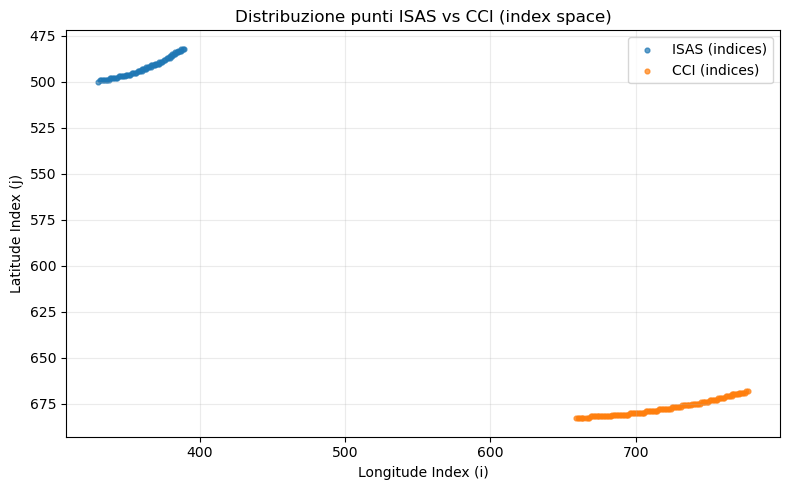

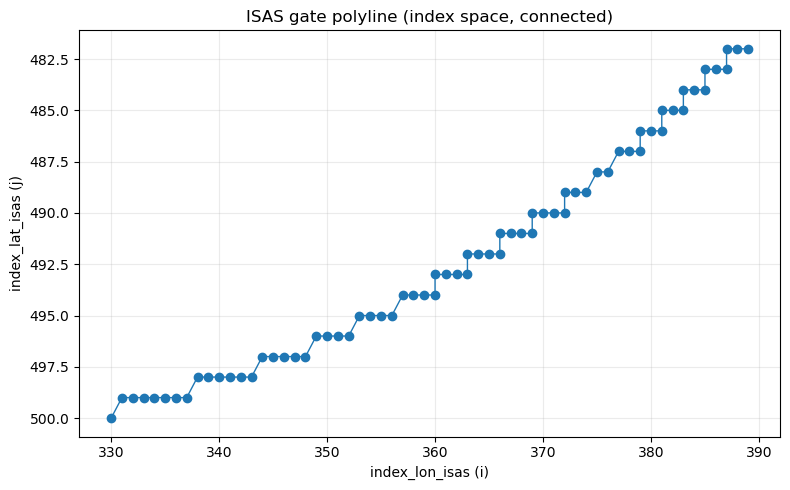

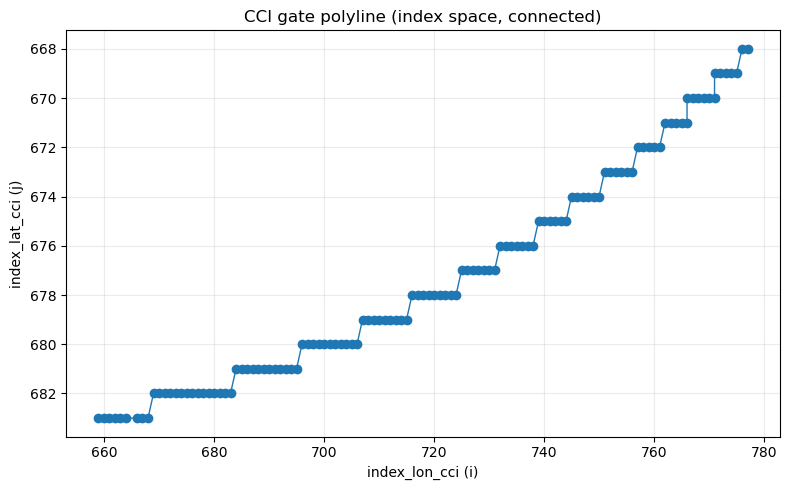


ISAS points: 70 total, 70 unique, 0 duplicated locations

Stats ISAS index_lon_isas: min=330, max=389, mean=362, n=70/70

Stats ISAS index_lat_isas: min=482, max=500, mean=492, n=70/70

CCI points: 120 total, 120 unique, 0 duplicated locations

Stats CCI index_lon_cci: min=659, max=777, mean=719, n=120/120

Stats CCI index_lat_cci: min=668, max=683, mean=677, n=120/120


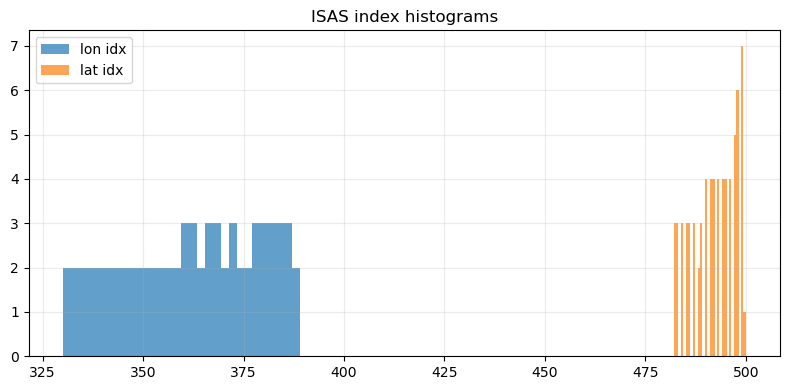

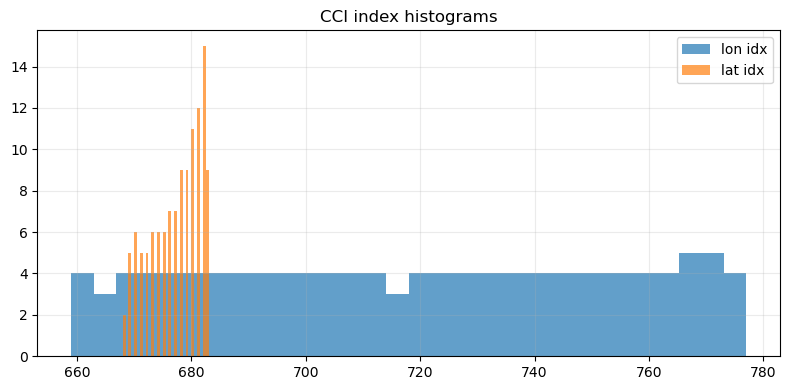


No non-index data variables to plot in this dataset.

Geo-space plot skipped: lon/lat grid not found in this dataset (or ISAS indices missing).

Done.


In [ ]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

# =========================
# 0) LOAD DATASET
# =========================
file = "/Users/nicolocaron/Desktop/ARCFRESH/straits/fram_strait_S3_pass_481.nc"
ds = xr.open_dataset(file)  # <- change path

# =========================
# 1) INSPECT DATASET
# =========================
print(ds)
print("\nVariabili disponibili (data_vars):", list(ds.data_vars))
print("Coordinate disponibili (coords):", list(ds.coords))
print("Dimensioni (sizes):", dict(ds.sizes))  # use sizes (dims mapping is changing)

# If you previously had KeyError due to case:
# print([v for v in ds.data_vars if v.lower() == "psal"])

# =========================
# 2) QUICK SUMMARY HELPERS
# =========================
def _safe_np(a):
    """Return numpy array from xarray DataArray/Dataset var."""
    return np.asarray(a.values)

def _basic_stats(arr, name=""):
    arr = np.asarray(arr)
    finite = np.isfinite(arr)
    if finite.any():
        print(f"\nStats {name}: min={arr[finite].min()}, max={arr[finite].max()}, "
              f"mean={arr[finite].mean():.3g}, n={finite.sum()}/{arr.size}")
    else:
        print(f"\nStats {name}: no finite values")

# =========================
# 3) PLOT ISAS/CCI INDEX DISTRIBUTION (SCATTER)
# =========================
fig, ax = plt.subplots(figsize=(8, 5))

has_isas = ("index_lon_isas" in ds) and ("index_lat_isas" in ds)
has_cci  = ("index_lon_cci"  in ds) and ("index_lat_cci"  in ds)

if has_isas:
    x_isas = _safe_np(ds["index_lon_isas"]).astype(int)
    y_isas = _safe_np(ds["index_lat_isas"]).astype(int)
    ax.scatter(x_isas, y_isas, label="ISAS (indices)", alpha=0.7, s=12)

if has_cci:
    x_cci = _safe_np(ds["index_lon_cci"]).astype(int)
    y_cci = _safe_np(ds["index_lat_cci"]).astype(int)
    ax.scatter(x_cci, y_cci, label="CCI (indices)", alpha=0.7, s=12)

ax.set_xlabel("Longitude Index (i)")
ax.set_ylabel("Latitude Index (j)")
ax.set_title("Distribuzione punti ISAS vs CCI (index space)")
ax.legend()
ax.invert_yaxis()  # common for row indices
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

# =========================
# 4) PLOT POLYLINES (CONNECT POINTS IN ORDER)
# =========================
if has_isas:
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(x_isas, y_isas, marker="o", linewidth=1)
    ax.set_title("ISAS gate polyline (index space, connected)")
    ax.set_xlabel("index_lon_isas (i)")
    ax.set_ylabel("index_lat_isas (j)")
    ax.invert_yaxis()
    ax.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()

if has_cci:
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(x_cci, y_cci, marker="o", linewidth=1)
    ax.set_title("CCI gate polyline (index space, connected)")
    ax.set_xlabel("index_lon_cci (i)")
    ax.set_ylabel("index_lat_cci (j)")
    ax.invert_yaxis()
    ax.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()

# =========================
# 5) DIAGNOSTICS: DUPLICATES + RANGE
# =========================
def _duplicates_report(x, y, label):
    pts = np.column_stack([x, y])
    uniq, counts = np.unique(pts, axis=0, return_counts=True)
    n_dup = np.sum(counts > 1)
    print(f"\n{label} points: {len(pts)} total, {len(uniq)} unique, {n_dup} duplicated locations")
    if n_dup > 0:
        # show a few duplicates
        dup_pts = uniq[counts > 1]
        print(f"Example duplicated points (first 10): {dup_pts[:10]}")

if has_isas:
    _duplicates_report(x_isas, y_isas, "ISAS")
    _basic_stats(x_isas, "ISAS index_lon_isas")
    _basic_stats(y_isas, "ISAS index_lat_isas")

if has_cci:
    _duplicates_report(x_cci, y_cci, "CCI")
    _basic_stats(x_cci, "CCI index_lon_cci")
    _basic_stats(y_cci, "CCI index_lat_cci")

# =========================
# 6) HISTOGRAMS OF INDICES (TO SEE SPREAD)
# =========================
if has_isas:
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(x_isas, bins=30, alpha=0.7, label="lon idx")
    ax.hist(y_isas, bins=30, alpha=0.7, label="lat idx")
    ax.set_title("ISAS index histograms")
    ax.legend()
    ax.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()

if has_cci:
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(x_cci, bins=30, alpha=0.7, label="lon idx")
    ax.hist(y_cci, bins=30, alpha=0.7, label="lat idx")
    ax.set_title("CCI index histograms")
    ax.legend()
    ax.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()

# =========================
# 7) AUTO-PLOT A "DATA" VARIABLE (YOUR ORIGINAL PART, BUT SAFER)
# =========================
# Prefer to avoid plotting index variables as "data snapshots"
avoid_vars = {"index_lon_isas", "index_lat_isas", "index_lon_cci", "index_lat_cci"}

candidate_vars = [v for v in ds.data_vars if v not in avoid_vars]
if len(candidate_vars) == 0:
    print("\nNo non-index data variables to plot in this dataset.")
else:
    # choose the first candidate
    var_name = candidate_vars[0]
    print(f"\nPlotto la variabile: {var_name}")
    da = ds[var_name]

    # If time-like dims exist, select first timestep
    time_like = [d for d in da.dims if d.lower() in ("time", "date")]
    sel = {}
    for d in time_like:
        sel[d] = 0

    # Also handle depth-like dims (common in ocean)
    for d in da.dims:
        if d.lower() in ("depth", "z", "lev", "level"):
            sel[d] = 0
            break

    da_plot = da.isel(**sel) if sel else da

    plt.figure(figsize=(8, 5))
    da_plot.plot()
    plt.title(f"{var_name} slice {sel if sel else ''}")
    plt.tight_layout()
    plt.show()

# =========================
# 8) OPTIONAL: GEO-SPACE PLOT IF LON/LAT GRIDS ARE AVAILABLE
# =========================
# This works ONLY if you have lon/lat arrays either in ds.coords or ds.data_vars.
# We'll try a few common names. If found, we map (j,i) -> (lat,lon) and plot.
def _find_var_any(ds, names):
    for n in names:
        if n in ds:
            return ds[n]
    return None

lon_var = _find_var_any(ds, ["lon", "longitude", "LON", "LONGITUDE"])
lat_var = _find_var_any(ds, ["lat", "latitude", "LAT", "LATITUDE"])

if lon_var is not None and lat_var is not None and has_isas:
    lon = _safe_np(lon_var)
    lat = _safe_np(lat_var)

    # Determine if lon/lat are 1D or 2D
    if lon.ndim == 2 and lat.ndim == 2:
        lon_pts = lon[y_isas, x_isas]
        lat_pts = lat[y_isas, x_isas]

        plt.figure(figsize=(8, 5))
        plt.plot(lon_pts, lat_pts, marker="o", linewidth=1)
        plt.title("ISAS gate in geo space (lon/lat from same ds)")
        plt.xlabel("Longitude")
        plt.ylabel("Latitude")
        plt.grid(True, alpha=0.25)
        plt.tight_layout()
        plt.show()

    elif lon.ndim == 1 and lat.ndim == 1:
        lon_pts = lon[x_isas]
        lat_pts = lat[y_isas]

        plt.figure(figsize=(8, 5))
        plt.plot(lon_pts, lat_pts, marker="o", linewidth=1)
        plt.title("ISAS gate in geo space (1D lon/lat vectors in same ds)")
        plt.xlabel("Longitude")
        plt.ylabel("Latitude")
        plt.grid(True, alpha=0.25)
        plt.tight_layout()
        plt.show()

    else:
        print("\nFound lon/lat but shapes are unusual; print shapes:")
        print("lon shape:", lon.shape, "lat shape:", lat.shape)
else:
    print("\nGeo-space plot skipped: lon/lat grid not found in this dataset (or ISAS indices missing).")

print("\nDone.")
